<a href="https://colab.research.google.com/github/OluPaul22/gis/blob/main/NJMuniTaxExp_Geo_Proxy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas pyogrio shapely pyproj geopy haversine openpyxl

In [ ]:
import pandas as pd #data management
import geopandas as gpd
import numpy as np

from pathlib import Path
from geopy.distance import geodesic

In [ ]:
pip install adjustText

In [ ]:
import os, zipfile #basics
import matplotlib.pyplot as plt #vis

!pip install contextily
import contextily as ctx

import mapclassify #need for thematic map classification

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

from google.colab import data_table
data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )

from matplotlib.patches import Patch
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.patheffects import withStroke #Import the withStroke object.

In [ ]:
print("pandas:", pd.__version__)
print("geopandas:", gpd.__version__)

pandas: 2.2.3
geopandas: 1.1.4


My Drive/cannabis_gis_project

In [ ]:
from google.colab import drive
# Forcefully remove any existing contents in the mount directory
!rm -rf /content/drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

mydrive = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424")
for item in mydrive.iterdir():
    print(item)

/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/NJ_Municipal_Boundaries_3424.shp.xml
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/NJ_Municipal_Boundaries_3424.prj
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/NJ_Municipal_Boundaries_3424.shx
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/NJ_Municipal_Boundaries_3424.shp
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/NJ_Municipal_Boundaries_3424.cpg
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/NJ_Municipal_Boundaries_3424.dbf
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ

In [ ]:
gdf = gpd.read_file(mydrive / "NJ_Municipal_Boundaries_3424.shp")
gdf.head()

,MUN,COUNTY,MUN_LABEL,MUN_TYPE,NAME,GNIS_NAME,GNIS,SSN,MUN_CODE,CENSUS2020,...,POP2010,POP2000,POP1990,POP1980,POPDEN2020,POPDEN2010,POPDEN2000,POPDEN1990,POPDEN1980,geometry
0,CAPE MAY POINT BORO,CAPE MAY,Cape May Point Borough,Borough,Cape May Point Borough,Borough of Cape May Point,885179,0503,0503,3400910330,...,291,241,248,255,1016,970,803,826,850,"POLYGON ((361324.555 36119.591, 361262.564 361..."
1,WEST CAPE MAY BORO,CAPE MAY,West Cape May Borough,Borough,West Cape May Borough,Borough of West Cape May,885435,0512,0512,3400978530,...,1024,1095,1026,1091,854,866,926,868,923,"POLYGON ((371013.281 40519.688, 372330.802 395..."
2,CAPE MAY CITY,CAPE MAY,Cape May City,City,Cape May,City of Cape May,885178,0502,0502,3400910270,...,3607,4034,4668,4853,960,1251,1399,1619,1684,"POLYGON ((385059.21 43411.44, 385135.71 43390...."
3,WILDWOOD CREST BORO,CAPE MAY,Wildwood Crest Borough,Borough,Wildwood Crest Borough,Borough of Wildwood Crest,885445,0515,0515,3400981200,...,3270,3980,3631,4149,2094,2208,2688,2452,2802,"POLYGON ((397386.178 55797.446, 397386.526 557..."
4,WEST WILDWOOD BORO,CAPE MAY,West Wildwood Borough,Borough,West Wildwood Borough,Borough of West Wildwood,885441,0513,0513,3400980210,...,603,448,453,360,1484,1657,1231,1245,990,"POLYGON ((401502.81 61708.99, 401592.22 61615...."


<Axes: >

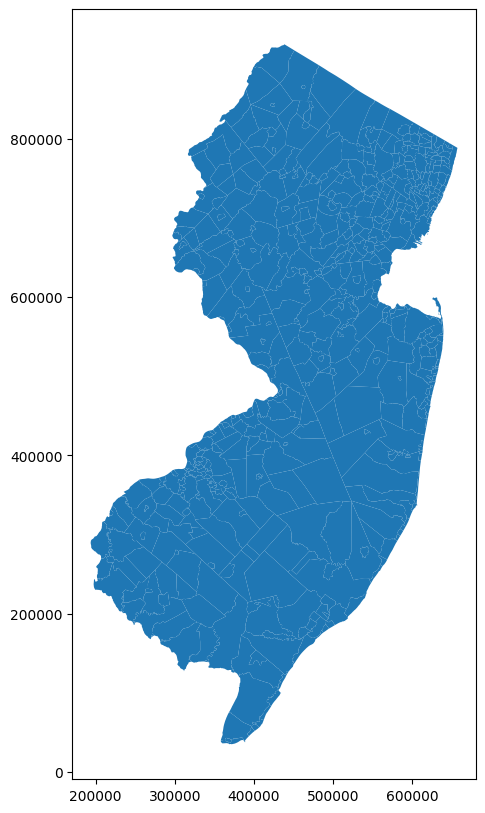

In [ ]:
njmuns = gdf
njmuns.plot(figsize=(10, 10))

In [ ]:
print("Shape:", njmuns.shape)

print("CRS:", njmuns.crs)

print("Columns:", list(njmuns.columns))

Shape: (564, 23)
CRS: EPSG:3424
Columns: ['MUN', 'COUNTY', 'MUN_LABEL', 'MUN_TYPE', 'NAME', 'GNIS_NAME', 'GNIS', 'SSN', 'MUN_CODE', 'CENSUS2020', 'ACRES', 'SQ_MILES', 'POP2020', 'POP2010', 'POP2000', 'POP1990', 'POP1980', 'POPDEN2020', 'POPDEN2010', 'POPDEN2000', 'POPDEN1990', 'POPDEN1980', 'geometry']


In [ ]:
display(njmuns[["SSN", "NAME", "MUN_LABEL", "MUN_CODE", "MUN_TYPE", "COUNTY"]].head(20))

,SSN,NAME,MUN_LABEL,MUN_CODE,MUN_TYPE,COUNTY
0,0503,Cape May Point Borough,Cape May Point Borough,0503,Borough,CAPE MAY
1,0512,West Cape May Borough,West Cape May Borough,0512,Borough,CAPE MAY
2,0502,Cape May,Cape May City,0502,City,CAPE MAY
3,0515,Wildwood Crest Borough,Wildwood Crest Borough,0515,Borough,CAPE MAY
4,0513,West Wildwood Borough,West Wildwood Borough,0513,Borough,CAPE MAY
5,0507,North Wildwood,North Wildwood City,0507,City,CAPE MAY
6,0505,Lower Township,Lower Township,0505,Township,CAPE MAY
7,0510,Stone Harbor Borough,Stone Harbor Borough,0510,Borough,CAPE MAY
8,0501,Avalon Borough,Avalon Borough,0501,Borough,CAPE MAY
9,0509,Sea Isle City,Sea Isle City,0509,City,CAPE MAY


In [ ]:
# Create centroids in original projected CRS

njmuns["centroid_geom"] = njmuns.geometry.centroid

# Convert centroids to latitude/longitude

centroids = gpd.GeoDataFrame(

    njmuns[["SSN", "NAME", "COUNTY", "MUN_LABEL", "MUN_TYPE"]].copy(),

    geometry=njmuns["centroid_geom"],

    crs=njmuns.crs

)

centroids_latlon = centroids.to_crs(epsg=4326)
centroids_latlon["longitude"] = centroids_latlon.geometry.x
centroids_latlon["latitude"] = centroids_latlon.geometry.y

In [ ]:
# Create clean Dataset 2

dataset2 = centroids_latlon.rename(columns={
    "SSN": "muni_id",
    "NAME": "muni_name",
    "COUNTY": "county",
    "MUN_LABEL": "muni_label",
    "MUN_TYPE": "muni_type"
})
dataset2 = dataset2[[
    "muni_id",
    "muni_name",
    "county",
    "muni_label",
    "muni_type",
    "latitude",
    "longitude"
]].copy()

In [ ]:
dataset2.head()

,muni_id,muni_name,county,muni_label,muni_type,latitude,longitude
0,0503,Cape May Point Borough,CAPE MAY,Cape May Point Borough,Borough,38.937327,-74.965196
1,0512,West Cape May Borough,CAPE MAY,West Cape May Borough,Borough,38.942268,-74.937793
2,0502,Cape May,CAPE MAY,Cape May City,City,38.940731,-74.903202
3,0515,Wildwood Crest Borough,CAPE MAY,Wildwood Crest Borough,Borough,38.971699,-74.837587
4,0513,West Wildwood Borough,CAPE MAY,West Wildwood Borough,Borough,39.000608,-74.823547


In [ ]:
# Ensure municipality ID is 4-character string

dataset2["muni_id"] = dataset2["muni_id"].astype(str).str.zfill(4)

# Final checks

print("Dataset 2 shape:", dataset2.shape)

print("Municipality ID length check:")

print(dataset2["muni_id"].str.len().value_counts())

display(dataset2.head(20))

Dataset 2 shape: (564, 7)
Municipality ID length check:
muni_id
4    564
Name: count, dtype: int64


,muni_id,muni_name,county,muni_label,muni_type,latitude,longitude
0,0503,Cape May Point Borough,CAPE MAY,Cape May Point Borough,Borough,38.937327,-74.965196
1,0512,West Cape May Borough,CAPE MAY,West Cape May Borough,Borough,38.942268,-74.937793
2,0502,Cape May,CAPE MAY,Cape May City,City,38.940731,-74.903202
3,0515,Wildwood Crest Borough,CAPE MAY,Wildwood Crest Borough,Borough,38.971699,-74.837587
4,0513,West Wildwood Borough,CAPE MAY,West Wildwood Borough,Borough,39.000608,-74.823547
5,0507,North Wildwood,CAPE MAY,North Wildwood City,City,39.004642,-74.798522
6,0505,Lower Township,CAPE MAY,Lower Township,Township,38.981987,-74.908559
7,0510,Stone Harbor Borough,CAPE MAY,Stone Harbor Borough,Borough,39.038551,-74.773104
8,0501,Avalon Borough,CAPE MAY,Avalon Borough,Borough,39.090213,-74.736136
9,0509,Sea Isle City,CAPE MAY,Sea Isle City,City,39.151754,-74.698241


In [ ]:
from pathlib import Path

# Main project folder where your shapefile is stored
project_path = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424")

# Create output folder inside the project folder
output_path = project_path / "created_datasets"
output_path.mkdir(parents=True, exist_ok=True)

print(output_path)

/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets


In [ ]:
csv_file = output_path / "dataset2_municipality_spatial_reference.csv"

dataset2.to_csv(csv_file, index=False)

print("Saved CSV to:")
print(csv_file)
print("File exists:", csv_file.exists())

Saved CSV to:
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/dataset2_municipality_spatial_reference.csv
File exists: True


In [ ]:
for item in output_path.iterdir():
    print(item.name)

dataset2_municipality_spatial_reference.csv


In [ ]:
dta_file = output_path / "dataset2_municipality_spatial_reference.dta"

dataset2.to_stata(
    dta_file,
    write_index=False,
    version=118
)

print("Saved Stata file to:")
print(dta_file)
print("File exists:", dta_file.exists())

Saved Stata file to:
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/dataset2_municipality_spatial_reference.dta
File exists: True


In [ ]:
for item in output_path.iterdir():
    print(item.name)

mun_geo.csv
mun_geo.dta
mun_pairs_full.csv
mun_pairs_full.dta
mun_pairs_20mi.csv
mun_pairs_20mi.dta
analytical_with_geo.csv
analytical_with_geo.dta
dataset2_municipality_spatial_reference.csv


In [ ]:
from pathlib import Path

# Make sure output_path is already defined
# If not, uncomment and edit this line:
# output_path = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets")

old_csv = output_path / "dataset2_municipality_spatial_reference.csv"
old_dta = output_path / "dataset2_municipality_spatial_reference.dta"

new_csv = output_path / "mun_geo.csv"
new_dta = output_path / "mun_geo.dta"

# Rename CSV
if old_csv.exists():
    old_csv.rename(new_csv)
    print("CSV renamed to:", new_csv.name)
else:
    print("Old CSV not found:", old_csv)

# Rename DTA
if old_dta.exists():
    old_dta.rename(new_dta)
    print("DTA renamed to:", new_dta.name)
else:
    print("Old DTA not found:", old_dta)

# Confirm folder contents
print("\nFiles now in output folder:")
for item in output_path.iterdir():
    print(item.name)

PosixPath('/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/mun_geo.csv')

CSV renamed to: mun_geo.csv
Old DTA not found: /content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/dataset2_municipality_spatial_reference.dta

Files now in output folder:
mun_geo.csv
mun_geo.dta
mun_pairs_full.csv
mun_pairs_full.dta
mun_pairs_20mi.csv
mun_pairs_20mi.dta
analytical_with_geo.csv
analytical_with_geo.dta


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Use your existing output_path
mun_geo = pd.read_csv(output_path / "mun_geo.csv", dtype={"muni_id": str})

mun_geo.head()

,muni_id,muni_name,county,muni_label,muni_type,latitude,longitude
0,0503,Cape May Point Borough,CAPE MAY,Cape May Point Borough,Borough,38.937327,-74.965196
1,0512,West Cape May Borough,CAPE MAY,West Cape May Borough,Borough,38.942268,-74.937793
2,0502,Cape May,CAPE MAY,Cape May City,City,38.940731,-74.903202
3,0515,Wildwood Crest Borough,CAPE MAY,Wildwood Crest Borough,Borough,38.971699,-74.837587
4,0513,West Wildwood Borough,CAPE MAY,West Wildwood Borough,Borough,39.000608,-74.823547


**Creating the municipality-pair dataset**

In [ ]:
# Keep only the variables needed for pair construction
a = mun_geo[["muni_id", "muni_name", "latitude", "longitude"]].copy()
b = mun_geo[["muni_id", "muni_name", "latitude", "longitude"]].copy()

# Rename variables for Municipality A
a = a.rename(columns={
    "muni_id": "muni_a_id",
    "muni_name": "muni_a_name",
    "latitude": "lat_a",
    "longitude": "lon_a"
})

# Rename variables for Municipality B
b = b.rename(columns={
    "muni_id": "muni_b_id",
    "muni_name": "muni_b_name",
    "latitude": "lat_b",
    "longitude": "lon_b"
})

# Cross join: every municipality A with every municipality B
a["key"] = 1
b["key"] = 1

mun_pairs = a.merge(b, on="key").drop(columns="key")

print(mun_pairs.shape)
mun_pairs.head()

(318096, 8)


,muni_a_id,muni_a_name,lat_a,lon_a,muni_b_id,muni_b_name,lat_b,lon_b
0,0503,Cape May Point Borough,38.937327,-74.965196,0503,Cape May Point Borough,38.937327,-74.965196
1,0503,Cape May Point Borough,38.937327,-74.965196,0512,West Cape May Borough,38.942268,-74.937793
2,0503,Cape May Point Borough,38.937327,-74.965196,0502,Cape May,38.940731,-74.903202
3,0503,Cape May Point Borough,38.937327,-74.965196,0515,Wildwood Crest Borough,38.971699,-74.837587
4,0503,Cape May Point Borough,38.937327,-74.965196,0513,West Wildwood Borough,39.000608,-74.823547


In [ ]:
## Calculating great-circle distance in miles

# Haversine distance formula, vectorized
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.7613  # Earth radius in miles

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    h = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(h))

mun_pairs["distance_miles"] = haversine_miles(
    mun_pairs["lat_a"],
    mun_pairs["lon_a"],
    mun_pairs["lat_b"],
    mun_pairs["lon_b"]
)

mun_pairs.head()

,muni_a_id,muni_a_name,lat_a,lon_a,muni_b_id,muni_b_name,lat_b,lon_b,distance_miles
0,0503,Cape May Point Borough,38.937327,-74.965196,0503,Cape May Point Borough,38.937327,-74.965196,0.000000
1,0503,Cape May Point Borough,38.937327,-74.965196,0512,West Cape May Borough,38.942268,-74.937793,1.511731
2,0503,Cape May Point Borough,38.937327,-74.965196,0502,Cape May,38.940731,-74.903202,3.340008
3,0503,Cape May Point Borough,38.937327,-74.965196,0515,Wildwood Crest Borough,38.971699,-74.837587,7.256135
4,0503,Cape May Point Borough,38.937327,-74.965196,0513,West Wildwood Borough,39.000608,-74.823547,8.776019


In [ ]:
## Creating Distance Indicators

mun_pairs["within_5_miles"] = (mun_pairs["distance_miles"] <= 5).astype(int)
mun_pairs["within_10_miles"] = (mun_pairs["distance_miles"] <= 10).astype(int)
mun_pairs["within_15_miles"] = (mun_pairs["distance_miles"] <= 15).astype(int)
mun_pairs["within_20_miles"] = (mun_pairs["distance_miles"] <= 20).astype(int)

mun_pairs.head()

,muni_a_id,muni_a_name,lat_a,lon_a,muni_b_id,muni_b_name,lat_b,lon_b,distance_miles,within_5_miles,within_10_miles,within_15_miles,within_20_miles
0,0503,Cape May Point Borough,38.937327,-74.965196,0503,Cape May Point Borough,38.937327,-74.965196,0.000000,1,1,1,1
1,0503,Cape May Point Borough,38.937327,-74.965196,0512,West Cape May Borough,38.942268,-74.937793,1.511731,1,1,1,1
2,0503,Cape May Point Borough,38.937327,-74.965196,0502,Cape May,38.940731,-74.903202,3.340008,1,1,1,1
3,0503,Cape May Point Borough,38.937327,-74.965196,0515,Wildwood Crest Borough,38.971699,-74.837587,7.256135,0,1,1,1
4,0503,Cape May Point Borough,38.937327,-74.965196,0513,West Wildwood Borough,39.000608,-74.823547,8.776019,0,1,1,1


In [ ]:
## Keeping final variables for dataset 3

dataset3 = mun_pairs[[
    "muni_a_id",
    "muni_a_name",
    "muni_b_id",
    "muni_b_name",
    "distance_miles",
    "within_5_miles",
    "within_10_miles",
    "within_15_miles",
    "within_20_miles"
]].copy()

dataset3.head()

,muni_a_id,muni_a_name,muni_b_id,muni_b_name,distance_miles,within_5_miles,within_10_miles,within_15_miles,within_20_miles
0,0503,Cape May Point Borough,0503,Cape May Point Borough,0.000000,1,1,1,1
1,0503,Cape May Point Borough,0512,West Cape May Borough,1.511731,1,1,1,1
2,0503,Cape May Point Borough,0502,Cape May,3.340008,1,1,1,1
3,0503,Cape May Point Borough,0515,Wildwood Crest Borough,7.256135,0,1,1,1
4,0503,Cape May Point Borough,0513,West Wildwood Borough,8.776019,0,1,1,1


In [ ]:
# Keep only municipality pairs within 20 miles
dataset3_20mi = dataset3[dataset3["distance_miles"] <= 20].copy()

print("Full pair dataset:", dataset3.shape)
print("Within-20-mile dataset:", dataset3_20mi.shape)

dataset3_20mi.head()

Full pair dataset: (318096, 9)
Within-20-mile dataset: (47966, 9)


,muni_a_id,muni_a_name,muni_b_id,muni_b_name,distance_miles,within_5_miles,within_10_miles,within_15_miles,within_20_miles
0,0503,Cape May Point Borough,0503,Cape May Point Borough,0.000000,1,1,1,1
1,0503,Cape May Point Borough,0512,West Cape May Borough,1.511731,1,1,1,1
2,0503,Cape May Point Borough,0502,Cape May,3.340008,1,1,1,1
3,0503,Cape May Point Borough,0515,Wildwood Crest Borough,7.256135,0,1,1,1
4,0503,Cape May Point Borough,0513,West Wildwood Borough,8.776019,0,1,1,1


In [ ]:
## Exporting Dataset3 as both the full pair dataset, and the within-20-mile dataset

# Export full pair dataset
dataset3.to_csv(output_path / "mun_pairs_full.csv", index=False)

dataset3.to_stata(
    output_path / "mun_pairs_full.dta",
    write_index=False,
    version=118
)

# Export within-20-mile working dataset
dataset3_20mi.to_csv(output_path / "mun_pairs_20mi.csv", index=False)

dataset3_20mi.to_stata(
    output_path / "mun_pairs_20mi.dta",
    write_index=False,
    version=118
)

print("Both full and within-20-mile pair datasets exported.")

Both full and within-20-mile pair datasets exported.


**Importing the Analytical Dataset**

In [ ]:
analytical = pd.read_stata(
    "/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/can_modified.dta"
)

In [ ]:
# Making sure municipality code is in 4 digits
analytical["muni_id"] = analytical["muni_id"].astype(str).str.zfill(4)

In [ ]:
## Checking if the municipal ids in the analytical and muni_geo dataset merges

mun_geo = pd.read_csv(output_path / "mun_geo.csv", dtype={"muni_id": str})

analytical_ids = analytical[["muni_id"]].drop_duplicates()
geo_ids = mun_geo[["muni_id", "muni_name", "county"]].drop_duplicates()

id_check = analytical_ids.merge(
    geo_ids,
    on="muni_id",
    how="outer",
    indicator=True
)

id_check["_merge"].value_counts()

,count
_merge,
both,564
left_only,1
right_only,0


In [ ]:
id_check[id_check["_merge"] == "left_only"]

,muni_id,muni_name,county,_merge
161,0429,NaN,NaN,left_only


In [ ]:
name_check = analytical[["muni_id", "muni_name"]].drop_duplicates().merge(
    mun_geo[["muni_id", "muni_name"]].rename(columns={"muni_name": "gis_muni_name"}),
    on="muni_id",
    how="left"
)

name_check["name_match"] = (
    name_check["muni_name"].str.upper().str.strip()
    ==
    name_check["gis_muni_name"].str.upper().str.strip()
)

name_check["name_match"].value_counts()

,count
name_match,
False,553
True,13


In [ ]:
name_check[name_check["name_match"] == False]

,muni_id,muni_name,gis_muni_name,name_match
0,0101,Absecon City,Absecon,False
2,0103,Brigantine City,Brigantine,False
3,0104,Buena Boro,Buena Borough,False
4,0105,Buena Vista Twp,Buena Vista Township,False
7,0108,Egg Harbor Twp,Egg Harbor Township,False
...,...,...,...,...
561,2119,Phillipsburg Town,Phillipsburg,False
562,2120,Pohatcong Twp,Pohatcong Township,False
563,2121,Washington Boro,Washington Borough,False
564,2122,Washington Twp,Washington Township,False


In [ ]:
del name_check
"name_check" in globals()

False

In [ ]:
# Removing the only municipal that did not merge "0429"

analytical = analytical[analytical["muni_id"] != "0429"].copy()
analytical["muni_id"].nunique()

564

In [ ]:
analytical_ids = analytical[["muni_id"]].drop_duplicates()
geo_ids = mun_geo[["muni_id", "muni_name", "county"]].drop_duplicates()

id_check = analytical_ids.merge(
    geo_ids,
    on="muni_id",
    how="outer",
    indicator=True
)

id_check["_merge"].value_counts()

,count
_merge,
both,564
left_only,0
right_only,0


Merging mun_geo with the analytical data

In [ ]:
analytical_geo = analytical.merge(
    mun_geo[["muni_id", "muni_name", "county", "latitude", "longitude"]],
    on="muni_id",
    how="left",
    suffixes=("", "_gis")
)

print("Missing latitude after merge:", analytical_geo["latitude"].isna().sum())

Missing latitude after merge: 0


In [ ]:
analytical_geo.to_csv(output_path / "analytical_with_geo.csv", index=False)

analytical_geo.to_stata(
    output_path / "analytical_with_geo.dta",
    write_index=False,
    version=118
)

In [ ]:
analytical_geo.head()

,muni_id,muni_name,year,can_rev,can_rev_pcap,can_active,opted_in,eff_tax_rate,mri_score,dem_vote,eqprop_val,state_rev,pop,age65_over,muni_name_gis,county,latitude,longitude
0,0101,Absecon City,2016.0,0.0,0.0,0.0,1.0,2.918781,-3.600225,50.310001,747805564.0,757801.940,8438.0,20.4,Absecon,ATLANTIC,39.42274,-74.49432
1,0101,Absecon City,2017.0,0.0,0.0,0.0,1.0,3.096136,-3.600225,50.310001,727840911.0,757801.945,8370.0,21.2,Absecon,ATLANTIC,39.42274,-74.49432
2,0101,Absecon City,2018.0,0.0,0.0,0.0,1.0,3.188293,-3.600225,50.310001,749575777.0,757801.950,8289.0,22.3,Absecon,ATLANTIC,39.42274,-74.49432
3,0101,Absecon City,2019.0,0.0,0.0,0.0,1.0,3.076000,-3.036593,50.310001,743893642.0,757801.940,8362.0,22.8,Absecon,ATLANTIC,39.42274,-74.49432
4,0101,Absecon City,2020.0,0.0,0.0,0.0,1.0,3.137155,-3.036593,50.310001,717707095.0,757801.860,8471.0,22.0,Absecon,ATLANTIC,39.42274,-74.49432


## **CREATING THE HYPOTHETICAL RETAILER DATASET**

### Cannabis Spatial Variable Prototype

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Base directory for the entire project
base_dir = Path(
    "/content/drive/MyDrive/"
    "2026_Dr. Hayes_SummerProjects/"
    "CannabisGISproject"
)

# Directory for GIS-related data (e.g., shapefiles)
gis_data_dir = base_dir / "NJ_Municipal_Boundaries_3424"

# Directory where intermediate and analytical datasets are stored
data_path = gis_data_dir / "created_datasets" # Corrected path to match actual save location

# Folder for prototype outputs
prototype_path = gis_data_dir / "prototype_spatial_variables"
prototype_path.mkdir(parents=True, exist_ok=True)

print("Input folder exists:", data_path.exists())
print("Prototype output folder:", prototype_path)

Input folder exists: True
Prototype output folder: /content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/prototype_spatial_variables


In [ ]:
# Load the municipality-pair file restricted to 20 miles.
# Municipality IDs are read as strings to preserve leading zeros.
import pandas as pd
from pathlib import Path

# Define data_path consistently and explicitly
base_dir = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject")
gis_data_dir = base_dir / "NJ_Municipal_Boundaries_3424"
data_path = gis_data_dir / "created_datasets" # Corrected path

pairs = pd.read_csv(
    data_path / "mun_pairs_20mi.csv",
    dtype=
        {
        "muni_a_id": str,
        "muni_b_id": str
    }
)

# Load the analytical municipality-year file.
analyTICAL = pd.read_stata(
    data_path / "analytical_with_geo.dta",
    convert_categoricals=False
)

# Standardize municipality IDs as four-character strings.
analyTICAL["muni_id"] = (
    analyTICAL["muni_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

pairs["muni_a_id"] = pairs["muni_a_id"].astype(str).str.zfill(4)
pairs["muni_b_id"] = pairs["muni_b_id"].astype(str).str.zfill(4)

print("Pair dataset shape:", pairs.shape)
print("Analytical dataset shape:", analyTICAL.shape)

print("\nAnalytical columns:")
print(list(analyTICAL.columns))
analyTICAL.head()

print("\nPair columns:")
print(list(pairs.columns))

Pair dataset shape: (47966, 9)
Analytical dataset shape: (5076, 18)

Analytical columns:
['muni_id', 'muni_name', 'year', 'can_rev', 'can_rev_pcap', 'can_active', 'opted_in', 'eff_tax_rate', 'mri_score', 'dem_vote', 'eqprop_val', 'state_rev', 'pop', 'age65_over', 'muni_name_gis', 'county', 'latitude', 'longitude']


,muni_id,muni_name,year,can_rev,can_rev_pcap,can_active,opted_in,eff_tax_rate,mri_score,dem_vote,eqprop_val,state_rev,pop,age65_over,muni_name_gis,county,latitude,longitude
0,0101,Absecon City,2016.0,0.0,0.0,0.0,1.0,2.918781,-3.600225,50.310001,747805564.0,757801.940,8438.0,20.4,Absecon,ATLANTIC,39.42274,-74.49432
1,0101,Absecon City,2017.0,0.0,0.0,0.0,1.0,3.096136,-3.600225,50.310001,727840911.0,757801.945,8370.0,21.2,Absecon,ATLANTIC,39.42274,-74.49432
2,0101,Absecon City,2018.0,0.0,0.0,0.0,1.0,3.188293,-3.600225,50.310001,749575777.0,757801.950,8289.0,22.3,Absecon,ATLANTIC,39.42274,-74.49432
3,0101,Absecon City,2019.0,0.0,0.0,0.0,1.0,3.076000,-3.036593,50.310001,743893642.0,757801.940,8362.0,22.8,Absecon,ATLANTIC,39.42274,-74.49432
4,0101,Absecon City,2020.0,0.0,0.0,0.0,1.0,3.137155,-3.036593,50.310001,717707095.0,757801.860,8471.0,22.0,Absecon,ATLANTIC,39.42274,-74.49432



Pair columns:
['muni_a_id', 'muni_a_name', 'muni_b_id', 'muni_b_name', 'distance_miles', 'within_5_miles', 'within_10_miles', 'within_15_miles', 'within_20_miles']


#### **Creating the hypothetical retailer data**

In [ ]:
# Loading the municipality reference data
import pandas as pd
from pathlib import Path

# Define data_path consistently and explicitly
base_dir = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject")
gis_data_dir = base_dir / "NJ_Municipal_Boundaries_3424"
data_path = gis_data_dir / "created_datasets" # Corrected path

mun_geo = pd.read_csv(
    data_path / "mun_geo.csv",
    dtype={"muni_id": str}
)

mun_geo["muni_id"] = mun_geo["muni_id"].str.zfill(4)

print(mun_geo.shape)
display(mun_geo.head())

(564, 7)


,muni_id,muni_name,county,muni_label,muni_type,latitude,longitude
0,0503,Cape May Point Borough,CAPE MAY,Cape May Point Borough,Borough,38.937327,-74.965196
1,0512,West Cape May Borough,CAPE MAY,West Cape May Borough,Borough,38.942268,-74.937793
2,0502,Cape May,CAPE MAY,Cape May City,City,38.940731,-74.903202
3,0515,Wildwood Crest Borough,CAPE MAY,Wildwood Crest Borough,Borough,38.971699,-74.837587
4,0513,West Wildwood Borough,CAPE MAY,West Wildwood Borough,Borough,39.000608,-74.823547


In [ ]:
# Sort municipalities to make the hypothetical example reproducible.
municipality_sample = (
    mun_geo[["muni_id", "muni_name"]]
    .drop_duplicates()
    .sort_values("muni_id")
    .reset_index(drop=True)
)

# Choose several valid municipalities from different positions
# in the statewide file.
selected = municipality_sample.iloc[
    [10, 45, 90, 140, 200, 280, 360, 440, 520]
].reset_index(drop=True)

display(selected)

,muni_id,muni_name
0,0111,Galloway Township
1,0223,Hackensack
2,0268,Woodcliff Lake Borough
3,0408,Camden
4,0702,Bloomfield Township
5,1024,Tewksbury Township
6,1341,Roosevelt Borough
7,1529,South Toms River Borough
8,1924,Wantage Township


In [ ]:
# CREATE HYPOTHETICAL EVENT-LEVEL RETAILER DATA
# Analytical period: 2016–2024
# Hypothetical openings occur during 2021–2024


hypothetical_retailers = pd.DataFrame({
    "retailer_id": [
        "R001", "R002", "R003", "R004",
        "R005", "R006", "R007", "R008",
        "R009", "R010", "R011", "R012"
    ],

    "retailer_name": [
        "Garden State Cannabis",
        "Garden State Cannabis II",
        "Central Jersey Green",
        "Central Jersey Green II",
        "North Star Cannabis",
        "South Jersey Wellness",
        "New Jersey Cannabis Market",
        "New Jersey Cannabis Market II",
        "Community Green",
        "Community Green II",
        "Atlantic Cannabis",
        "Garden Retail Group"
    ],

    # Municipality IDs are drawn from valid municipalities
    # in the municipal spatial reference dataset.
    "muni_id": [
        selected.loc[0, "muni_id"],
        selected.loc[0, "muni_id"],  # same municipality, later opening
        selected.loc[1, "muni_id"],
        selected.loc[1, "muni_id"],  # same municipality, later opening
        selected.loc[2, "muni_id"],
        selected.loc[3, "muni_id"],
        selected.loc[4, "muni_id"],
        selected.loc[4, "muni_id"],  # same municipality, later opening
        selected.loc[5, "muni_id"],
        selected.loc[5, "muni_id"],  # same municipality, later opening
        selected.loc[6, "muni_id"],
        selected.loc[7, "muni_id"]
    ],

    # Hypothetical opening dates fall within 2021–2024.
    "opening_date": [
        "2021-06-15",
        "2024-08-10",
        "2022-03-01",
        "2024-01-20",
        "2023-07-14",
        "2021-11-05",
        "2022-09-30",
        "2023-05-12",
        "2023-02-01",
        "2024-06-01",
        "2023-10-18",
        "2022-04-25"
    ]
})

# Convert opening dates from strings to Python dates.
hypothetical_retailers["opening_date"] = pd.to_datetime(
    hypothetical_retailers["opening_date"]
)

# Extract the opening year.
hypothetical_retailers["opening_year"] = (
    hypothetical_retailers["opening_date"].dt.year
)

# Attach municipality names for readability and verification.
hypothetical_retailers = hypothetical_retailers.merge(
    mun_geo[["muni_id", "muni_name"]],
    on="muni_id",
    how="left",
    validate="many_to_one"
)

# Arrange variables in a logical order.
hypothetical_retailers = hypothetical_retailers[[
    "retailer_id",
    "retailer_name",
    "muni_id",
    "muni_name",
    "opening_date",
    "opening_year"
]]

display(hypothetical_retailers)

,retailer_id,retailer_name,muni_id,muni_name,opening_date,opening_year
0,R001,Garden State Cannabis,0111,Galloway Township,2021-06-15,2021
1,R002,Garden State Cannabis II,0111,Galloway Township,2024-08-10,2024
2,R003,Central Jersey Green,0223,Hackensack,2022-03-01,2022
3,R004,Central Jersey Green II,0223,Hackensack,2024-01-20,2024
4,R005,North Star Cannabis,0268,Woodcliff Lake Borough,2023-07-14,2023
5,R006,South Jersey Wellness,0408,Camden,2021-11-05,2021
6,R007,New Jersey Cannabis Market,0702,Bloomfield Township,2022-09-30,2022
7,R008,New Jersey Cannabis Market II,0702,Bloomfield Township,2023-05-12,2023
8,R009,Community Green,1024,Tewksbury Township,2023-02-01,2023
9,R010,Community Green II,1024,Tewksbury Township,2024-06-01,2024


In [ ]:
display(analytical)

,muni_id,muni_name,year,can_rev,can_rev_pcap,can_active,opted_in,eff_tax_rate,mri_score,dem_vote,eqprop_val,state_rev,pop,age65_over,muni_name_gis,county,latitude,longitude
0,0101,Absecon City,2016.0,0.0,0.0,0.0,1.0,2.918781,-3.600225,50.310001,747805564.0,757801.940,8438.0,20.4,Absecon,ATLANTIC,39.422740,-74.494320
1,0101,Absecon City,2017.0,0.0,0.0,0.0,1.0,3.096136,-3.600225,50.310001,727840911.0,757801.945,8370.0,21.2,Absecon,ATLANTIC,39.422740,-74.494320
2,0101,Absecon City,2018.0,0.0,0.0,0.0,1.0,3.188293,-3.600225,50.310001,749575777.0,757801.950,8289.0,22.3,Absecon,ATLANTIC,39.422740,-74.494320
3,0101,Absecon City,2019.0,0.0,0.0,0.0,1.0,3.076000,-3.036593,50.310001,743893642.0,757801.940,8362.0,22.8,Absecon,ATLANTIC,39.422740,-74.494320
4,0101,Absecon City,2020.0,0.0,0.0,0.0,1.0,3.137155,-3.036593,50.310001,717707095.0,757801.860,8471.0,22.0,Absecon,ATLANTIC,39.422740,-74.494320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5071,2123,White Twp,2020.0,0.0,0.0,0.0,0.0,2.125869,0.120483,24.790001,570012994.0,311056.000,4685.0,39.7,White Township,WARREN,40.821675,-75.041319
5072,2123,White Twp,2021.0,0.0,0.0,0.0,0.0,2.222000,0.120483,27.100000,578830821.0,318792.000,4638.0,41.0,White Township,WARREN,40.821675,-75.041319
5073,2123,White Twp,2022.0,0.0,0.0,0.0,0.0,2.200496,-0.523613,27.100000,677965106.0,311056.000,4635.0,39.3,White Township,WARREN,40.821675,-75.041319
5074,2123,White Twp,2023.0,0.0,0.0,0.0,0.0,1.957326,-0.523613,27.100000,736052250.0,331107.320,4646.0,39.8,White Township,WARREN,40.821675,-75.041319


In [ ]:
## Saving the new hypothetical data

hypothetical_retailers.to_csv(
    prototype_path / "hypo_retailers.csv",
    index=False
)

hypothetical_retailers.to_stata(
    prototype_path / "hypo_retailers.dta",
    write_index=False,
    version=118
)

Hypothetical retailer dataset saved.


**Old Code (Ends)**

### Creating the complete municipality-year skeleton

In [ ]:
# Create one observation for every municipality-year
# contained in the analytical dataset.

import pandas as pd
from pathlib import Path

# Define column names as string literals
muni_id = 'muni_id'
year = 'year'

# Explicitly define data_path to ensure the analytical file can be found.
base_dir = Path(
    "/content/drive/MyDrive/"
    "2026_Dr. Hayes_SummerProjects/"
    "CannabisGISproject"
)
gis_data_dir = base_dir / "NJ_Municipal_Boundaries_3424"
data_path = gis_data_dir / "created_datasets" # Corrected path

# Load the analytical municipality-year file.
analytical = pd.read_stata(
    data_path / "analytical_with_geo.dta",
    convert_categoricals=False
)

municipality_year = (
    analytical[[muni_id, year]]
    .drop_duplicates()
    .copy()
)

# Restrict to the actual analytical period.
municipality_year = municipality_year[
    municipality_year[year].between(2016, 2024)
].copy()

print("Municipality-year skeleton shape:", municipality_year.shape)
print("Years included:", sorted(municipality_year[year].unique()))

display(municipality_year.head())

Municipality-year skeleton shape: (5076, 2)
Years included: [np.float32(2016.0), np.float32(2017.0), np.float32(2018.0), np.float32(2019.0), np.float32(2020.0), np.float32(2021.0), np.float32(2022.0), np.float32(2023.0), np.float32(2024.0)]


,muni_id,year
0,0101,2016.0
1,0101,2017.0
2,0101,2018.0
3,0101,2019.0
4,0101,2020.0


updating prototype-year code

In [ ]:
## Opening_year ≤ observation year

prototype_years = pd.DataFrame({
    year: sorted(municipality_year[year].unique())
})


# Cross-join retailer records with prototype years.prototype_years = pd.DataFrame({YEAR_VAR: list(range(2021, 2026))})

retailer_year = hypothetical_retailers.merge(
    prototype_years,
    how="cross"
)

# Retain years in which the retailer is already operating.
retailer_year = retailer_year[
    retailer_year[year] >= retailer_year["opening_year"]
].copy()

# Count active retailers by municipality-year.
active_counts = (
    retailer_year
    .groupby(["muni_id", year], as_index=False)
    .agg(active_retailers=("retailer_id", "nunique"))
)

# Merge counts into the complete municipality-year skeleton.

retailer_panel = municipality_year.merge(
    active_counts,
    left_on=[muni_id, year],
    right_on=["muni_id", year],
    how="left"
)

retailer_panel["year"] = retailer_panel["year"].astype(int)

# Remove duplicate merge key if names differ.
if muni_id != "muni_id":
    retailer_panel = retailer_panel.drop(columns=["muni_id"])

# Municipalities with no retailer receive zero.
retailer_panel["active_retailers"] = (
    retailer_panel["active_retailers"]
    .fillna(0)
    .astype(int)
)

# Additional supply indicators.
retailer_panel["retailer_present"] = (
    retailer_panel["active_retailers"] > 0
).astype(int)

display(
    retailer_panel[
        retailer_panel["active_retailers"] > 0
    ].sort_values([muni_id, year])
)

,muni_id,year,active_retailers,retailer_present
213,0201,2022,1,1
214,0201,2023,2,1
215,0201,2024,2,1
267,0207,2022,1,1
268,0207,2023,2,1
...,...,...,...,...
4838,2017,2021,1,1
4839,2017,2022,1,1
4840,2017,2023,1,1
4841,2017,2024,1,1


## Preparing the analytical, retailer and pair files

In [ ]:
## Preparing Input Datasets

import pandas as pd
import numpy as np
from pathlib import Path

# Define data_path consistently and explicitly
base_dir = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject")
gis_data_dir = base_dir / "NJ_Municipal_Boundaries_3424"
data_path = gis_data_dir / "created_datasets" # Corrected path


# Variable names in the analytical dataset
ID_VAR = "muni_id"
YEAR_VAR = "year"
POP_VAR = "pop"

# Re-loading analytical here to ensure it's available.
analyTICAL = pd.read_stata(
    data_path / "analytical_with_geo.dta",
    convert_categoricals=False
)

# 1. Standardize municipality IDs and years

analyTICAL[ID_VAR] = (
    analyTICAL[ID_VAR]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

analyTICAL[YEAR_VAR] = (
    pd.to_numeric(analyTICAL[YEAR_VAR], errors="raise")
    .astype(int)
)

retailer_panel[ID_VAR] = (
    retailer_panel[ID_VAR]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

retailer_panel[YEAR_VAR] = (
    pd.to_numeric(retailer_panel[YEAR_VAR], errors="raise")
    .astype(int)
)


# 2. Load the pair datasets explicitly

pairs20 = pd.read_csv(
    data_path / "mun_pairs_20mi.csv",
    dtype={
        "muni_a_id": str,
        "muni_b_id": str
    }
)

pairs_full = pd.read_csv(
    data_path / "mun_pairs_full.csv",
    dtype={
        "muni_a_id": str,
        "muni_b_id": str
    }
)

pairs20["muni_a_id"] = pairs20["muni_a_id"].str.zfill(4)
pairs20["muni_b_id"] = pairs20["muni_b_id"].str.zfill(4)

pairs_full["muni_a_id"] = pairs_full["muni_a_id"].str.zfill(4)
pairs_full["muni_b_id"] = pairs_full["muni_b_id"].str.zfill(4)


# 3. Create one population observation per municipality-year

population_panel = analyTICAL[
    [ID_VAR, YEAR_VAR, POP_VAR]
].copy()

# Confirm that municipality-year uniquely identifies each row.
duplicate_population_rows = population_panel.duplicated(
    subset=[ID_VAR, YEAR_VAR],
    keep=False
)

if duplicate_population_rows.any():
    display(
        population_panel[
            duplicate_population_rows
        ].sort_values([ID_VAR, YEAR_VAR])
    )

    raise ValueError(
        "The population panel has duplicate municipality-year rows.")


# 4. Combine population with active-retailer counts

municipality_year_attributes = population_panel.merge(
    retailer_panel[
        [ID_VAR, YEAR_VAR, "active_retailers", "retailer_present"]
    ],
    on=[ID_VAR, YEAR_VAR],
    how="left",
    validate="one_to_one"
)

# Any municipality-year without a retailer count receives zero.
municipality_year_attributes["active_retailers"] = (
    municipality_year_attributes["active_retailers"]
    .fillna(0)
    .astype(int)
)

municipality_year_attributes["retailer_present"] = (
    municipality_year_attributes["retailer_present"]
    .fillna(0)
    .astype(int)
)

print("Population panel:", population_panel.shape)
print(
    "Municipality-year attributes:",
    municipality_year_attributes.shape
)

display(municipality_year_attributes.head(20))

Population panel: (5076, 3)
Municipality-year attributes: (5076, 5)


,muni_id,year,pop,active_retailers,retailer_present
0,0101,2016,8438.0,0,0
1,0101,2017,8370.0,0,0
2,0101,2018,8289.0,0,0
3,0101,2019,8362.0,0,0
4,0101,2020,8471.0,0,0
5,0101,2021,9039.0,0,0
6,0101,2022,9086.0,0,0
7,0101,2023,9099.0,0,0
8,0101,2024,9112.0,0,0
9,0102,2016,39306.0,0,0


In [ ]:
## CREATE MUNICIPALITY A–B–YEAR DATASET


# Use the exact years in the retailer panel.
prototype_years = pd.DataFrame({
    YEAR_VAR: sorted(retailer_panel[YEAR_VAR].unique())
})

print("Prototype years:")
print(prototype_years[YEAR_VAR].tolist())

# Repeat every municipality pair for each year.
pair_year = pairs20.merge(
    prototype_years,
    how="cross"
)

# Prepare Municipality B's annual attributes.
b_attributes = municipality_year_attributes.rename(columns={
    ID_VAR: "muni_b_id",
    POP_VAR: "population_b",
    "active_retailers": "active_retailers_b",
    "retailer_present": "retailer_present_b"
})

b_attributes = b_attributes[[
    "muni_b_id",
    YEAR_VAR,
    "population_b",
    "active_retailers_b",
    "retailer_present_b"
]]

# Attach Municipality B's annual population and retailer status.
pair_year = pair_year.merge(
    b_attributes,
    on=["muni_b_id", YEAR_VAR],
    how="left",
    validate="many_to_one"
)

# Check for missing annual information.
print(
    "Missing Municipality B populations:",
    pair_year["population_b"].isna().sum()
)

print(
    "Missing Municipality B retailer counts:",
    pair_year["active_retailers_b"].isna().sum()
)

if pair_year["population_b"].isna().any():
    raise ValueError(
        "Some Municipality B-year observations are missing population."
    )

pair_year["active_retailers_b"] = (
    pair_year["active_retailers_b"]
    .fillna(0)
    .astype(int)
)

# Identify Municipality A paired with itself.
pair_year["self_pair"] = (
    pair_year["muni_a_id"] == pair_year["muni_b_id"]
)

print("Expanded pair-year dataset:", pair_year.shape)

display(
    pair_year[[
        "muni_a_id",
        "muni_a_name",
        "muni_b_id",
        "muni_b_name",
        YEAR_VAR,
        "distance_miles",
        "population_b",
        "active_retailers_b",
        "self_pair"
    ]].head(20)
)

Prototype years:
[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Missing Municipality B populations: 0
Missing Municipality B retailer counts: 0
Expanded pair-year dataset: (431694, 14)


,muni_a_id,muni_a_name,muni_b_id,muni_b_name,year,distance_miles,population_b,active_retailers_b,self_pair
0,0503,Cape May Point Borough,0503,Cape May Point Borough,2016,0.000000,214.0,0,True
1,0503,Cape May Point Borough,0503,Cape May Point Borough,2017,0.000000,204.0,0,True
2,0503,Cape May Point Borough,0503,Cape May Point Borough,2018,0.000000,188.0,0,True
3,0503,Cape May Point Borough,0503,Cape May Point Borough,2019,0.000000,176.0,0,True
4,0503,Cape May Point Borough,0503,Cape May Point Borough,2020,0.000000,165.0,0,True
5,0503,Cape May Point Borough,0503,Cape May Point Borough,2021,0.000000,150.0,0,True
6,0503,Cape May Point Borough,0503,Cape May Point Borough,2022,0.000000,155.0,0,True
7,0503,Cape May Point Borough,0503,Cape May Point Borough,2023,0.000000,155.0,0,True
8,0503,Cape May Point Borough,0503,Cape May Point Borough,2024,0.000000,155.0,0,True
9,0503,Cape May Point Borough,0512,West Cape May Borough,2016,1.511731,955.0,0,False


In [ ]:
# CONSTRUCT RADIUS-BASED CONTRIBUTIONS


radii = [5, 10, 15, 20]

for radius in radii:

    # Is Municipality B within this radius of Municipality A?
    within_radius = (
        pair_year["distance_miles"] <= radius
    )


    # External demand: Population of other municipalities with zero retailers.


    pair_year[f"nearby_no_retail_pop_{radius}"] = np.where(
        within_radius
        & (~pair_year["self_pair"])
        & (pair_year["active_retailers_b"] == 0),

        pair_year["population_b"],
        0
    )


    # Total retailers within the radius.
    # Includes Municipality A's own retailers.


    pair_year[f"retailers_within_{radius}"] = np.where(
        within_radius,
        pair_year["active_retailers_b"],
        0
    )


    # Retailers in other municipalities within the radius.
    # Excludes Municipality A's own retailers.


    pair_year[f"other_retailers_within_{radius}"] = np.where(
        within_radius & (~pair_year["self_pair"]),
        pair_year["active_retailers_b"],
        0
    )

# Variables that will be summed by Municipality A-year.
external_demand_variables = [
    f"nearby_no_retail_pop_{radius}"
    for radius in radii
]

total_retailer_variables = [
    f"retailers_within_{radius}"
    for radius in radii
]

other_retailer_variables = [
    f"other_retailers_within_{radius}"
    for radius in radii
]

variables_to_sum = (
    external_demand_variables
    + total_retailer_variables
    + other_retailer_variables
)

# Collapse back to one row per Municipality A-year.
spatial_variables = (
    pair_year
    .groupby(
        ["muni_a_id", YEAR_VAR],
        as_index=False
    )[variables_to_sum]
    .sum()
)

# Retailer-count variables should be integers.
for variable in (
    total_retailer_variables
    + other_retailer_variables
):
    spatial_variables[variable] = (
        spatial_variables[variable].astype(int)
    )

print("Collapsed spatial-variable dataset:")
print(spatial_variables.shape)

display(spatial_variables.head(25))

Collapsed spatial-variable dataset:
(5076, 14)


,muni_a_id,year,nearby_no_retail_pop_5,nearby_no_retail_pop_10,nearby_no_retail_pop_15,nearby_no_retail_pop_20,retailers_within_5,retailers_within_10,retailers_within_15,retailers_within_20,other_retailers_within_5,other_retailers_within_10,other_retailers_within_15,other_retailers_within_20
0,0101,2016,105533.0,155475.0,331057.0,358227.0,0,0,0,0,0,0,0,0
1,0101,2017,105152.0,154784.0,330380.0,357410.0,0,0,0,0,0,0,0,0
2,0101,2018,103527.0,152246.0,326992.0,353938.0,0,0,0,0,0,0,0,0
3,0101,2019,102547.0,150624.0,325460.0,352166.0,0,0,0,0,0,0,0,0
4,0101,2020,101923.0,149535.0,325070.0,351457.0,0,0,0,0,0,0,0,0
5,0101,2021,67405.0,113625.0,297253.0,323731.0,1,1,1,1,1,1,1,1
6,0101,2022,67481.0,113447.0,298595.0,325226.0,1,1,1,1,1,1,1,1
7,0101,2023,67517.0,113436.0,299841.0,326282.0,1,1,1,1,1,1,1,1
8,0101,2024,67553.0,113425.0,301087.0,327338.0,2,2,2,2,2,2,2,2
9,0102,2016,54964.0,123603.0,179784.0,325378.0,0,0,0,0,0,0,0,0


In [ ]:
# CALCULATE NEAREST-RETAILER DISTANCES


# Complete set of focal Municipality A IDs.
municipality_a_ids = (
    retailer_panel[[ID_VAR]]
    .drop_duplicates()
    .rename(columns={ID_VAR: "muni_a_id"})
    .sort_values("muni_a_id")
)

nearest_results = []

for current_year in sorted(
    retailer_panel[YEAR_VAR].unique()
):

    # Municipalities with at least one active retailer
    # in the current year.
    active_b = (
        retailer_panel[
            (retailer_panel[YEAR_VAR] == current_year)
            & (retailer_panel["active_retailers"] > 0)
        ][[ID_VAR]]
        .drop_duplicates()
        .rename(columns={ID_VAR: "muni_b_id"})
    )

    # Start with all Municipality A observations.
    year_result = municipality_a_ids.copy()
    year_result[YEAR_VAR] = current_year

    # If no retailer is active anywhere in the state,
    # nearest distances are undefined/missing.
    if active_b.empty:

        year_result["nearest_retailer_miles"] = np.nan
        year_result["nearest_other_retailer_miles"] = np.nan

    else:

        # Keep pair observations where Municipality B
        # has at least one active retailer.
        retailer_candidates = pairs_full.merge(
            active_b,
            on="muni_b_id",
            how="inner",
            validate="many_to_one"
        )

        # Nearest retailer, including a retailer in
        # Municipality A itself.
        nearest_any = (
            retailer_candidates
            .groupby("muni_a_id", as_index=False)
            .agg(
                nearest_retailer_miles=(
                    "distance_miles",
                    "min"
                )
            )
        )

        # Nearest retailer in another municipality.
        nearest_other = (
            retailer_candidates[
                retailer_candidates["muni_a_id"]
                != retailer_candidates["muni_b_id"]
            ]
            .groupby("muni_a_id", as_index=False)
            .agg(
                nearest_other_retailer_miles=(
                    "distance_miles",
                    "min"
                )
            )
        )

        year_result = year_result.merge(
            nearest_any,
            on="muni_a_id",
            how="left",
            validate="one_to_one"
        )

        year_result = year_result.merge(
            nearest_other,
            on="muni_a_id",
            how="left",
            validate="one_to_one"
        )

    nearest_results.append(year_result)

nearest_distances = pd.concat(
    nearest_results,
    ignore_index=True
)

print("Nearest-retailer dataset:")
print(nearest_distances.shape)

display(
    nearest_distances[
        nearest_distances["nearest_retailer_miles"].notna()
    ].head(20)
)

Nearest-retailer dataset:
(5076, 4)


,muni_a_id,year,nearest_retailer_miles,nearest_other_retailer_miles
2820,0101,2021,4.806617,4.806617
2821,0102,2021,7.823119,7.823119
2822,0103,2021,7.598587,7.598587
2823,0104,2021,24.966855,24.966855
2824,0105,2021,21.887336,21.887336
2825,0106,2021,18.215857,18.215857
2826,0107,2021,8.017753,8.017753
2827,0108,2021,10.486348,10.486348
2828,0109,2021,18.274544,18.274544
2829,0110,2021,20.604052,20.604052


In [ ]:
# CREATE FINAL PROTOTYPE SPATIAL-VARIABLE DATASET


# Local municipality retailer supply.
local_supply = retailer_panel[[
    ID_VAR,
    YEAR_VAR,
    "active_retailers",
    "retailer_present"
]].rename(columns={
    ID_VAR: "muni_a_id"
})

# Merge local supply into the radius-based measures.
prototype_variables = spatial_variables.merge(
    local_supply,
    on=["muni_a_id", YEAR_VAR],
    how="left",
    validate="one_to_one"
)

# Merge nearest-retailer distances.
prototype_variables = prototype_variables.merge(
    nearest_distances,
    on=["muni_a_id", YEAR_VAR],
    how="left",
    validate="one_to_one"
)

# Attach Municipality A's name and county.
municipality_names = (
    mun_geo[["muni_id", "muni_name", "county"]]
    .drop_duplicates()
    .rename(columns={
        "muni_id": "muni_a_id"
    })
)

prototype_variables = prototype_variables.merge(
    municipality_names,
    on="muni_a_id",
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# Effective-only-retail-municipality indicators
#
# Definition:
# Municipality A has at least one local retailer, but there
# are no retailers in any OTHER municipality within the radius.
#
# A municipality may have more than one local retailer and
# still qualify as the only retail municipality in the area.
# ------------------------------------------------------------

for radius in radii:

    prototype_variables[
        f"only_retail_municipality_{radius}"
    ] = (
        (prototype_variables["active_retailers"] > 0)
        & (
            prototype_variables[
                f"other_retailers_within_{radius}"
            ] == 0
        )
    ).astype(int)

    # Alternative stricter definition:
    # Exactly one total retailer exists within the radius,
    # and that retailer is located in Municipality A.
    prototype_variables[
        f"exactly_one_retailer_within_{radius}"
    ] = (
        (prototype_variables["active_retailers"] == 1)
        & (
            prototype_variables[
                f"retailers_within_{radius}"
            ] == 1
        )
    ).astype(int)

# Optional interaction variables corresponding to the memo.
for radius in radii:

    prototype_variables[
        f"supply_x_external_demand_{radius}"
    ] = (
        prototype_variables["active_retailers"]
        * prototype_variables[
            f"nearby_no_retail_pop_{radius}"
        ]
    )

# Rename focal municipality ID.
prototype_variables = prototype_variables.rename(columns={
    "muni_a_id": "muni_id"
})

# Arrange and sort the file.
prototype_variables = prototype_variables.sort_values(
    ["muni_id", YEAR_VAR]
).reset_index(drop=True)

print("Final prototype dataset:")
print(prototype_variables.shape)

display(prototype_variables.head(20))

Final prototype dataset:
(5076, 32)


,muni_id,year,nearby_no_retail_pop_5,nearby_no_retail_pop_10,nearby_no_retail_pop_15,nearby_no_retail_pop_20,retailers_within_5,retailers_within_10,retailers_within_15,retailers_within_20,...,only_retail_municipality_10,exactly_one_retailer_within_10,only_retail_municipality_15,exactly_one_retailer_within_15,only_retail_municipality_20,exactly_one_retailer_within_20,supply_x_external_demand_5,supply_x_external_demand_10,supply_x_external_demand_15,supply_x_external_demand_20
0,0101,2016,105533.0,155475.0,331057.0,358227.0,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
1,0101,2017,105152.0,154784.0,330380.0,357410.0,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
2,0101,2018,103527.0,152246.0,326992.0,353938.0,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
3,0101,2019,102547.0,150624.0,325460.0,352166.0,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
4,0101,2020,101923.0,149535.0,325070.0,351457.0,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
5,0101,2021,67405.0,113625.0,297253.0,323731.0,1,1,1,1,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
6,0101,2022,67481.0,113447.0,298595.0,325226.0,1,1,1,1,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
7,0101,2023,67517.0,113436.0,299841.0,326282.0,1,1,1,1,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
8,0101,2024,67553.0,113425.0,301087.0,327338.0,2,2,2,2,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
9,0102,2016,54964.0,123603.0,179784.0,325378.0,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0


In [ ]:
# VALIDATION CHECKS


number_of_municipalities = (
    prototype_variables["muni_id"].nunique()
)

number_of_years = (
    prototype_variables[YEAR_VAR].nunique()
)

expected_rows = (
    number_of_municipalities * number_of_years
)

print("Municipalities:", number_of_municipalities)
print("Years:", number_of_years)
print("Expected rows:", expected_rows)
print("Actual rows:", len(prototype_variables))

# Confirm one row per municipality-year.
print(
    "Duplicate municipality-year rows:",
    prototype_variables.duplicated(
        ["muni_id", YEAR_VAR]
    ).sum()
)

# External-demand measures should increase or remain equal
# as the radius becomes larger.
external_demand_order_correct = (
    (
        prototype_variables["nearby_no_retail_pop_5"]
        <= prototype_variables["nearby_no_retail_pop_10"]
    )
    & (
        prototype_variables["nearby_no_retail_pop_10"]
        <= prototype_variables["nearby_no_retail_pop_15"]
    )
    & (
        prototype_variables["nearby_no_retail_pop_15"]
        <= prototype_variables["nearby_no_retail_pop_20"]
    )
).all()

print(
    "External-demand radius ordering correct:",
    external_demand_order_correct
)

# Retailer counts should also increase or remain equal
# as the radius expands.
retailer_count_order_correct = (
    (
        prototype_variables["retailers_within_5"]
        <= prototype_variables["retailers_within_10"]
    )
    & (
        prototype_variables["retailers_within_10"]
        <= prototype_variables["retailers_within_15"]
    )
    & (
        prototype_variables["retailers_within_15"]
        <= prototype_variables["retailers_within_20"]
    )
).all()

print(
    "Retailer-count radius ordering correct:",
    retailer_count_order_correct
)

# Every municipality with a local retailer should have
# a nearest-retailer distance of zero.
local_retailer_rows = (
    prototype_variables["active_retailers"] > 0
)

nearest_zero_check = np.allclose(
    prototype_variables.loc[
        local_retailer_rows,
        "nearest_retailer_miles"
    ],
    0
)

print(
    "Local-retailer nearest distance equals zero:",
    nearest_zero_check
)

# Show statewide annual retailer totals.
annual_retailer_check = (
    prototype_variables
    .groupby(YEAR_VAR, as_index=False)
    .agg(
        statewide_active_retailers=(
            "active_retailers",
            "sum"
        ),
        municipalities_with_retailers=(
            "retailer_present",
            "sum"
        )
    )
)

display(annual_retailer_check)

Municipalities: 564
Years: 9
Expected rows: 5076
Actual rows: 5076
Duplicate municipality-year rows: 0
External-demand radius ordering correct: True
Retailer-count radius ordering correct: True
Local-retailer nearest distance equals zero: True


,year,statewide_active_retailers,municipalities_with_retailers
0,2016,0,0
1,2017,0,0
2,2018,0,0
3,2019,0,0
4,2020,0,0
5,2021,2,2
6,2022,5,5
7,2023,9,8
8,2024,12,8


In [ ]:
# FINALIZE AND EXPORT PROTOTYPE DATASETS


import pandas as pd
from pathlib import Path

# Confirm the output folder exists
prototype_path.mkdir(parents=True, exist_ok=True)

# Standardize key variables before exporting

hypothetical_retailers_export = hypothetical_retailers.copy()
retailer_panel_export = retailer_panel.copy()
prototype_variables_export = prototype_variables.copy()
analytical_export = analytical.copy()

# Preserve leading zeros in municipality IDs
hypothetical_retailers_export["muni_id"] = (
    hypothetical_retailers_export["muni_id"]
    .astype(str)
    .str.zfill(4)
)

retailer_panel_export["muni_id"] = (
    retailer_panel_export["muni_id"]
    .astype(str)
    .str.zfill(4)
)

prototype_variables_export["muni_id"] = (
    prototype_variables_export["muni_id"]
    .astype(str)
    .str.zfill(4)
)

analytical_export["muni_id"] = (
    analytical_export["muni_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

# Store year as an integer
retailer_panel_export["year"] = pd.to_numeric(
    retailer_panel_export["year"],
    errors="raise"
).astype(int)

prototype_variables_export["year"] = pd.to_numeric(
    prototype_variables_export["year"],
    errors="raise"
).astype(int)

analytical_export["year"] = pd.to_numeric(
    analytical_export["year"],
    errors="raise"
).astype(int)

# Export the hypothetical event-level retailer data

hypothetical_retailers_export.to_stata(
    prototype_path / "prototype_hypothetical_retailers.dta",
    write_index=False,
    version=118
)

hypothetical_retailers_export.to_csv(
    prototype_path / "prototype_hypothetical_retailers.csv",
    index=False
)

# Export the municipality-year retailer panel

retailer_panel_export.to_stata(
    prototype_path / "prototype_retailer_panel.dta",
    write_index=False,
    version=118
)

retailer_panel_export.to_csv(
    prototype_path / "prototype_retailer_panel.csv",
    index=False
)

# Export the final prototype spatial variables

prototype_variables_export.to_stata(
    prototype_path / "prototype_spatial_variables.dta",
    write_index=False,
    version=118
)

prototype_variables_export.to_csv(
    prototype_path / "prototype_spatial_variables.csv",
    index=False
)

print("The three prototype construction datasets were exported.")

The three prototype construction datasets were exported.


In [ ]:
# MERGE PROTOTYPE VARIABLES INTO THE ANALYTICAL PANEL

prototype_for_merge = prototype_variables_export.drop(
    columns=["muni_name", "county"],
    errors="ignore"
)

analytical_with_prototype = analytical_export.merge(
    prototype_for_merge,
    on=["muni_id", "year"],
    how="left",
    validate="one_to_one",
    indicator=True
)

# Check the merge result
print(analytical_with_prototype["_merge"].value_counts())

# Every row should match
if not (
    analytical_with_prototype["_merge"] == "both"
).all():
    unmatched = analytical_with_prototype[
        analytical_with_prototype["_merge"] != "both"
    ]

    display(unmatched[["muni_id", "year", "_merge"]])

    raise ValueError(
        "Some analytical municipality-year observations did not match."
    )

# Remove the temporary merge-check variable
analytical_with_prototype = analytical_with_prototype.drop(
    columns="_merge"
)

# Final checks
print("Final merged shape:", analytical_with_prototype.shape)

print(
    "Duplicate municipality-year rows:",
    analytical_with_prototype.duplicated(
        ["muni_id", "year"]
    ).sum()
)

print(
    "Municipalities:",
    analytical_with_prototype["muni_id"].nunique()
)

print(
    "Years:",
    sorted(analytical_with_prototype["year"].unique())
)

_merge
both          5076
left_only        0
right_only       0
Name: count, dtype: int64
Final merged shape: (5076, 46)
Duplicate municipality-year rows: 0
Municipalities: 564
Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
# Export

analytical_with_prototype.to_stata(
    prototype_path / "analytical_with_prototype_spatial_vars.dta",
    write_index=False,
    version=118
)

analytical_with_prototype.to_csv(
    prototype_path / "analytical_with_prototype_spatial_vars.csv",
    index=False
)

print("Final analytical prototype dataset exported.")

Final analytical prototype dataset exported.


**Week 2 Task**

**New Code (begins)**

In [ ]:
# CREATE 50 HYPOTHETICAL RETAILER RECORDS

import pandas as pd
import numpy as np

# Set a random seed so the hypothetical data are reproducible.
rng = np.random.default_rng(2026)

# Create a clean list of valid municipalities from mun_geo.
municipality_pool = (
    mun_geo[["muni_id", "muni_name"]]
    .drop_duplicates()
    .sort_values("muni_id")
    .reset_index(drop=True)
)

# Select 35 different municipalities to host retailers.
host_municipalities = municipality_pool.sample(
    n=35,
    random_state=2026
).reset_index(drop=True)

# Every selected municipality receives at least one retailer.
first_retailer_hosts = host_municipalities["muni_id"].tolist()

# Fifteen of the municipalities receive a second retailer.
second_retailer_hosts = (
    host_municipalities
    .sample(n=15, random_state=2027)["muni_id"]
    .tolist()
)

# This produces exactly 50 retailer records:
# 35 first retailers + 15 second retailers.
retailer_muni_ids = np.array(
    first_retailer_hosts + second_retailer_hosts,
    dtype=object
)

# Randomize the order of municipality assignments.
rng.shuffle(retailer_muni_ids)

# Assign openings across 2021–2024.
# Total = 10 + 12 + 14 + 14 = 50 retailers.
opening_years = np.array(
    [2021] * 10
    + [2022] * 12
    + [2023] * 14
    + [2024] * 14
)

rng.shuffle(opening_years)

# Generate a random opening date within each assigned year.
opening_dates = []

for opening_year in opening_years:

    first_day = pd.Timestamp(
        year=int(opening_year),
        month=1,
        day=1
    )

    last_day = pd.Timestamp(
        year=int(opening_year),
        month=12,
        day=31
    )

    number_of_days = (last_day - first_day).days + 1

    random_day = int(
        rng.integers(0, number_of_days)
    )

    opening_dates.append(
        first_day + pd.Timedelta(days=random_day)
    )

# Create the event-level hypothetical retailer dataset.
hypothetical_retailers = pd.DataFrame({
    "retailer_id": [
        f"R{i:03d}" for i in range(1, 51)
    ],

    "retailer_name": [
        f"Hypothetical Cannabis Retailer {i:03d}"
        for i in range(1, 51)
    ],

    "muni_id": retailer_muni_ids,

    "opening_date": opening_dates
})

# Standardize municipality IDs.
hypothetical_retailers["muni_id"] = (
    hypothetical_retailers["muni_id"]
    .astype(str)
    .str.zfill(4)
)

# Create the opening-year variable.
hypothetical_retailers["opening_year"] = (
    hypothetical_retailers["opening_date"].dt.year
)

# Attach municipality names.
hypothetical_retailers = hypothetical_retailers.merge(
    mun_geo[["muni_id", "muni_name"]],
    on="muni_id",
    how="left",
    validate="many_to_one"
)

# Arrange columns.
hypothetical_retailers = hypothetical_retailers[[
    "retailer_id",
    "retailer_name",
    "muni_id",
    "muni_name",
    "opening_date",
    "opening_year"
]]

# Validation checks.
assert len(hypothetical_retailers) == 50
assert hypothetical_retailers["muni_id"].nunique() == 35
assert hypothetical_retailers["muni_name"].notna().all()

print(
    "Number of hypothetical retailers:",
    len(hypothetical_retailers)
)

print(
    "Municipalities with hypothetical retailers:",
    hypothetical_retailers["muni_id"].nunique()
)

print("\nRetailers by opening year:")

display(
    hypothetical_retailers
    .groupby("opening_year")
    .size()
    .rename("number_of_retailers")
    .reset_index()
)

display(hypothetical_retailers.head(20))

Number of hypothetical retailers: 50
Municipalities with hypothetical retailers: 35

Retailers by opening year:


,opening_year,number_of_retailers
0,2021,10
1,2022,12
2,2023,14
3,2024,14


,retailer_id,retailer_name,muni_id,muni_name,opening_date,opening_year
0,R001,Hypothetical Cannabis Retailer 001,1205,Edison Township,2022-11-21,2022
1,R002,Hypothetical Cannabis Retailer 002,0602,Commercial Township,2022-12-17,2022
2,R003,Hypothetical Cannabis Retailer 003,0240,Northvale Borough,2024-08-15,2024
3,R004,Hypothetical Cannabis Retailer 004,0207,Closter Borough,2022-04-19,2022
4,R005,Hypothetical Cannabis Retailer 005,0437,Woodlynne Borough,2024-02-28,2024
5,R006,Hypothetical Cannabis Retailer 006,0201,Allendale Borough,2023-02-08,2023
6,R007,Hypothetical Cannabis Retailer 007,0201,Allendale Borough,2022-12-12,2022
7,R008,Hypothetical Cannabis Retailer 008,0602,Commercial Township,2023-04-09,2023
8,R009,Hypothetical Cannabis Retailer 009,0513,West Wildwood Borough,2024-01-09,2024
9,R010,Hypothetical Cannabis Retailer 010,0319,Maple Shade Township,2021-01-14,2021


In [ ]:
hypothetical_retailers.to_csv(
    prototype_path / "hypo_retailers.csv",
    index=False
)

hypothetical_retailers.to_stata(
    prototype_path / "hypo_retailers.dta",
    write_index=False,
    version=118
)

In [ ]:
# CREATE SEPARATE COPIES OF ALL REQUIRED INPUT DATASETS


import pandas as pd
import numpy as np
from pathlib import Path

# These variable names should be the same ones that worked
# in the earlier prototype.
ID_VAR = "muni_id"
YEAR_VAR = "year"

# Keep the population variable name you previously used.
# Change "pop" only if your analytical population column
# has a different name.
POP_VAR = "pop"

# Create completely separate Task 1 copies.
task1_analytical = analytical.copy()
task1_geo = mun_geo.copy()
task1_pairs20 = pairs20.copy()
task1_pairs_full = pairs_full.copy()

# The object hypothetical_retailers should now contain
# the new 50-retailer dataset you just created.
task1_retailers = hypothetical_retailers.copy()

# Create a separate output folder for this week's assignment.
task1_output_path = Path(
    "/content/drive/MyDrive/"
    "2026_Dr. Hayes_SummerProjects/"
    "CannabisGISproject/"
    "Task1_50RetailerPrototype"
)

task1_output_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Task 1 output folder:")
print(task1_output_path)

print("\nHypothetical retailers:")
print(task1_retailers.shape)

print("\nAnalytical data:")
print(task1_analytical.shape)

Task 1 output folder:
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/Task1_50RetailerPrototype

Hypothetical retailers:
(50, 6)

Analytical data:
(5076, 18)


In [ ]:
# STANDARDIZE MUNICIPALITY IDS, YEARS, AND OPENING DATES


# Standardize analytical municipality IDs.
task1_analytical[ID_VAR] = (
    task1_analytical[ID_VAR]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

# Standardize analytical years.
task1_analytical[YEAR_VAR] = (
    pd.to_numeric(
        task1_analytical[YEAR_VAR],
        errors="raise"
    )
    .astype(int)
)

# Standardize hypothetical retailer municipality IDs.
task1_retailers["muni_id"] = (
    task1_retailers["muni_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

# Ensure opening dates are proper dates.
task1_retailers["opening_date"] = pd.to_datetime(
    task1_retailers["opening_date"]
)

# Recreate opening year to ensure it is correct.
task1_retailers["opening_year"] = (
    task1_retailers["opening_date"]
    .dt.year
    .astype(int)
)

# Standardize municipality-pair IDs.
for pair_data in [task1_pairs20, task1_pairs_full]:

    pair_data["muni_a_id"] = (
        pair_data["muni_a_id"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(4)
    )

    pair_data["muni_b_id"] = (
        pair_data["muni_b_id"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(4)
    )

# Confirm that the population variable exists.
if POP_VAR not in task1_analytical.columns:

    raise KeyError(
        f"{POP_VAR} was not found. "
        f"Available columns are: "
        f"{list(task1_analytical.columns)}"
    )

print("Municipality IDs and years standardized.")
print(
    "Hypothetical opening years:",
    sorted(task1_retailers["opening_year"].unique())
)

Municipality IDs and years standardized.
Hypothetical opening years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
# CREATE ONE OBSERVATION PER MUNICIPALITY-YEAR


task1_municipality_year = (
    task1_analytical[
        [ID_VAR, YEAR_VAR]
    ]
    .drop_duplicates()
    .copy()
)

# Restrict the prototype to the analytical period.
task1_municipality_year = (
    task1_municipality_year[
        task1_municipality_year[YEAR_VAR]
        .between(2016, 2024)
    ]
    .copy()
)

task1_municipality_year = (
    task1_municipality_year
    .sort_values([ID_VAR, YEAR_VAR])
    .reset_index(drop=True)
)

# Create the year file used in later cross joins.
task1_years = pd.DataFrame({
    YEAR_VAR: sorted(
        task1_municipality_year[
            YEAR_VAR
        ].unique()
    )
})

print(
    "Municipalities:",
    task1_municipality_year[
        ID_VAR
    ].nunique()
)

print(
    "Years:",
    task1_years[YEAR_VAR].tolist()
)

print(
    "Municipality-year observations:",
    len(task1_municipality_year)
)

Municipalities: 564
Years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Municipality-year observations: 5076


In [ ]:
# CONVERT RETAILER OPENINGS INTO ACTIVE RETAILER COUNTS

# Pair each retailer with every analytical year.
task1_retailer_year = task1_retailers.merge(
    task1_years,
    how="cross"
)

# A retailer is active during its opening year and every
# subsequent year.
task1_retailer_year = task1_retailer_year[
    task1_retailer_year[YEAR_VAR]
    >= task1_retailer_year["opening_year"]
].copy()

# Count active retailers in each municipality-year.
task1_active_counts = (
    task1_retailer_year
    .groupby(
        ["muni_id", YEAR_VAR],
        as_index=False
    )
    .agg(
        active_retailers=(
            "retailer_id",
            "nunique"
        )
    )
)

# Merge counts into the complete municipality-year skeleton.
task1_retailer_panel = (
    task1_municipality_year
    .merge(
        task1_active_counts,
        on=["muni_id", YEAR_VAR],
        how="left",
        validate="one_to_one"
    )
)

# Municipalities without an active retailer receive zero.
task1_retailer_panel[
    "active_retailers"
] = (
    task1_retailer_panel[
        "active_retailers"
    ]
    .fillna(0)
    .astype(int)
)

# Check statewide totals.
task1_annual_retailer_check = (
    task1_retailer_panel
    .groupby(YEAR_VAR, as_index=False)
    .agg(
        statewide_active_retailers=(
            "active_retailers",
            "sum"
        ),
        municipalities_with_retailers=(
            "active_retailers",
            lambda values: (
                values > 0
            ).sum()
        )
    )
)

display(task1_annual_retailer_check)

,year,statewide_active_retailers,municipalities_with_retailers
0,2016,0,0
1,2017,0,0
2,2018,0,0
3,2019,0,0
4,2020,0,0
5,2021,10,9
6,2022,22,20
7,2023,36,27
8,2024,50,35


In [ ]:
# PREPARE MUNICIPALITY-YEAR POPULATION AND RETAILER ATTRIBUTES

task1_population_panel = (
    task1_analytical[
        [ID_VAR, YEAR_VAR, POP_VAR]
    ]
    .drop_duplicates(
        subset=[ID_VAR, YEAR_VAR]
    )
    .copy()
)

# Confirm one population record per municipality-year.
if task1_population_panel.duplicated(
    [ID_VAR, YEAR_VAR]
).any():

    raise ValueError(
        "Population data contain duplicate "
        "municipality-year observations."
    )

# Add active-retailer counts to the population panel.
task1_municipality_attributes = (
    task1_population_panel
    .merge(
        task1_retailer_panel,
        on=[ID_VAR, YEAR_VAR],
        how="left",
        validate="one_to_one"
    )
)

task1_municipality_attributes[
    "active_retailers"
] = (
    task1_municipality_attributes[
        "active_retailers"
    ]
    .fillna(0)
    .astype(int)
)

# Rename the variables because these values describe
# Municipality B in the pair dataset.
task1_b_attributes = (
    task1_municipality_attributes
    .rename(columns={
        ID_VAR: "muni_b_id",
        POP_VAR: "population_b",
        "active_retailers":
            "active_retailers_b"
    })
)

task1_b_attributes = task1_b_attributes[[
    "muni_b_id",
    YEAR_VAR,
    "population_b",
    "active_retailers_b"
]]

display(task1_b_attributes.head())

,muni_b_id,year,population_b,active_retailers_b
0,0101,2016,8438.0,0
1,0101,2017,8370.0,0
2,0101,2018,8289.0,0
3,0101,2019,8362.0,0
4,0101,2020,8471.0,0


In [ ]:
# CREATE MUNICIPALITY A–MUNICIPALITY B–YEAR DATA


# Keep only pair variables required for this task.
task1_pairs20_core = task1_pairs20[[
    "muni_a_id",
    "muni_a_name",
    "muni_b_id",
    "muni_b_name",
    "distance_miles"
]].copy()

# Repeat every pair for each year.
task1_pair_year = (
    task1_pairs20_core
    .merge(
        task1_years,
        how="cross"
    )
)

# Add Municipality B's annual population and retailer count.
task1_pair_year = (
    task1_pair_year
    .merge(
        task1_b_attributes,
        on=["muni_b_id", YEAR_VAR],
        how="left",
        validate="many_to_one"
    )
)

# Identify cases where Municipality A is paired with itself.
task1_pair_year["self_pair"] = (
    task1_pair_year["muni_a_id"]
    == task1_pair_year["muni_b_id"]
)

# Validate the merge.
print(
    "Missing Municipality B population:",
    task1_pair_year[
        "population_b"
    ].isna().sum()
)

print(
    "Missing Municipality B retailer count:",
    task1_pair_year[
        "active_retailers_b"
    ].isna().sum()
)

if task1_pair_year[
    "population_b"
].isna().any():

    raise ValueError(
        "Some Municipality B population values are missing."
    )

print(
    "Expanded Municipality A–B–year observations:",
    len(task1_pair_year)
)

Missing Municipality B population: 0
Missing Municipality B retailer count: 0
Expanded Municipality A–B–year observations: 431694


In [ ]:
# CALCULATE NO-RETAIL POPULATION AND NEARBY RETAILERS


task1_radii = [5, 10, 15, 20]

for radius in task1_radii:

    task1_within_radius = (
        task1_pair_year[
            "distance_miles"
        ] <= radius
    )

    # Nearby population without local retail access.
    #
    # Self-pairs are excluded because the variable represents
    # population outside the focal municipality.
    task1_pair_year[
        f"no_retail_pop_{radius}"
    ] = np.where(
        task1_within_radius
        & (~task1_pair_year["self_pair"])
        & (
            task1_pair_year[
                "active_retailers_b"
            ] == 0
        ),
        task1_pair_year["population_b"],
        0
    )

    # Number of active retailers within the radius.

    # Self-pairs are included, so local retailers are counted.
    task1_pair_year[
        f"retailers_within_{radius}"
    ] = np.where(
        task1_within_radius,
        task1_pair_year[
            "active_retailers_b"
        ],
        0
    )

task1_variables_to_sum = (
    [
        f"no_retail_pop_{radius}"
        for radius in task1_radii
    ]
    +
    [
        f"retailers_within_{radius}"
        for radius in task1_radii
    ]
)

# Collapse back to one row per focal municipality-year.
task1_radius_variables = (
    task1_pair_year
    .groupby(
        ["muni_a_id", YEAR_VAR],
        as_index=False
    )[task1_variables_to_sum]
    .sum()
)

for radius in task1_radii:

    task1_radius_variables[
        f"retailers_within_{radius}"
    ] = (
        task1_radius_variables[
            f"retailers_within_{radius}"
        ]
        .astype(int)
    )

display(task1_radius_variables.head())

,muni_a_id,year,no_retail_pop_5,no_retail_pop_10,no_retail_pop_15,no_retail_pop_20,retailers_within_5,retailers_within_10,retailers_within_15,retailers_within_20
0,0101,2016,105533.0,155475.0,331057.0,358227.0,0,0,0,0
1,0101,2017,105152.0,154784.0,330380.0,357410.0,0,0,0,0
2,0101,2018,103527.0,152246.0,326992.0,353938.0,0,0,0,0
3,0101,2019,102547.0,150624.0,325460.0,352166.0,0,0,0,0
4,0101,2020,101923.0,149535.0,325070.0,351457.0,0,0,0,0


In [ ]:
# CALCULATE DISTANCE TO THE NEAREST ACTIVE RETAILER

task1_pairs_full_core = task1_pairs_full[[
    "muni_a_id",
    "muni_b_id",
    "distance_miles"
]].copy()

task1_focal_municipalities = (
    task1_retailer_panel[
        ["muni_id"]
    ]
    .drop_duplicates()
    .rename(columns={
        "muni_id": "muni_a_id"
    })
)

task1_nearest_results = []

for current_year in task1_years[YEAR_VAR]:

    # Municipalities containing one or more active retailers.
    task1_active_host_municipalities = (
        task1_retailer_panel[
            (
                task1_retailer_panel[
                    YEAR_VAR
                ] == current_year
            )
            &
            (
                task1_retailer_panel[
                    "active_retailers"
                ] > 0
            )
        ][["muni_id"]]
        .drop_duplicates()
        .rename(columns={
            "muni_id": "muni_b_id"
        })
    )

    task1_year_nearest = (
        task1_focal_municipalities.copy()
    )

    task1_year_nearest[
        YEAR_VAR
    ] = current_year

    # Before the first retailer opens, nearest distance
    # is undefined.
    if task1_active_host_municipalities.empty:

        task1_year_nearest[
            "nearest_retailer_miles"
        ] = np.nan

    else:

        task1_retailer_candidates = (
            task1_pairs_full_core
            .merge(
                task1_active_host_municipalities,
                on="muni_b_id",
                how="inner",
                validate="many_to_one"
            )
        )

        task1_nearest_in_year = (
            task1_retailer_candidates
            .groupby(
                "muni_a_id",
                as_index=False
            )
            .agg(
                nearest_retailer_miles=(
                    "distance_miles",
                    "min"
                )
            )
        )

        task1_year_nearest = (
            task1_year_nearest
            .merge(
                task1_nearest_in_year,
                on="muni_a_id",
                how="left",
                validate="one_to_one"
            )
        )

    task1_nearest_results.append(
        task1_year_nearest
    )

task1_nearest_retailer = pd.concat(
    task1_nearest_results,
    ignore_index=True
)

display(
    task1_nearest_retailer[
        task1_nearest_retailer[
            "nearest_retailer_miles"
        ].notna()
    ].head()
)

,muni_a_id,year,nearest_retailer_miles
2820,0101,2021,30.407406
2821,0102,2021,33.668691
2822,0103,2021,36.387676
2823,0104,2021,6.095976
2824,0105,2021,8.907253


In [ ]:
# CREATE THE FINAL STREAMLINED MUNICIPALITY-YEAR DATASET

# Prepare local active-retailer counts.
task1_local_supply = (
    task1_retailer_panel
    .rename(columns={
        "muni_id": "muni_a_id"
    })[[
        "muni_a_id",
        YEAR_VAR,
        "active_retailers"
    ]]
)

# Combine radius variables with local supply.
task1_final = (
    task1_radius_variables
    .merge(
        task1_local_supply,
        on=["muni_a_id", YEAR_VAR],
        how="left",
        validate="one_to_one"
    )
)

# Add nearest-retailer distance.
task1_final = (
    task1_final
    .merge(
        task1_nearest_retailer,
        on=["muni_a_id", YEAR_VAR],
        how="left",
        validate="one_to_one"
    )
)

# Create effective-only-retailer indicators.

# The indicator equals 1 when:
# 1. Municipality A has at least one active retailer; and
# 2. All retailers within the radius are located inside A.

# In other words, no surrounding municipality within the
# radius has an active retailer.
for radius in task1_radii:

    task1_final[
        f"only_retailer_{radius}"
    ] = (
        (
            task1_final[
                "active_retailers"
            ] > 0
        )
        &
        (
            task1_final[
                f"retailers_within_{radius}"
            ]
            ==
            task1_final[
                "active_retailers"
            ]
        )
    ).astype(int)

# Add municipality name and county.
task1_reference = (
    task1_geo[
        ["muni_id", "muni_name", "county"]
    ]
    .drop_duplicates()
    .rename(columns={
        "muni_id": "muni_a_id"
    })
)

task1_final = (
    task1_final
    .merge(
        task1_reference,
        on="muni_a_id",
        how="left",
        validate="many_to_one"
    )
)

task1_final = task1_final.rename(
    columns={
        "muni_a_id": "muni_id"
    }
)

# Retain only variables requested for this week's task.
task1_final_columns = [
    "muni_id",
    "muni_name",
    "county",
    YEAR_VAR,
    "active_retailers",
    "no_retail_pop_5",
    "no_retail_pop_10",
    "no_retail_pop_15",
    "no_retail_pop_20",
    "retailers_within_5",
    "retailers_within_10",
    "retailers_within_15",
    "retailers_within_20",
    "nearest_retailer_miles",
    "only_retailer_5",
    "only_retailer_10",
    "only_retailer_15",
    "only_retailer_20"
]

task1_final = (
    task1_final[
        task1_final_columns
    ]
    .sort_values(
        ["muni_id", YEAR_VAR]
    )
    .reset_index(drop=True)
)

print("Final Task 1 shape:")
print(task1_final.shape)

display(task1_final.head(20))

Final Task 1 shape:
(5076, 18)


,muni_id,muni_name,county,year,active_retailers,no_retail_pop_5,no_retail_pop_10,no_retail_pop_15,no_retail_pop_20,retailers_within_5,retailers_within_10,retailers_within_15,retailers_within_20,nearest_retailer_miles,only_retailer_5,only_retailer_10,only_retailer_15,only_retailer_20
0,0101,Absecon,ATLANTIC,2016,0,105533.0,155475.0,331057.0,358227.0,0,0,0,0,NaN,0,0,0,0
1,0101,Absecon,ATLANTIC,2017,0,105152.0,154784.0,330380.0,357410.0,0,0,0,0,NaN,0,0,0,0
2,0101,Absecon,ATLANTIC,2018,0,103527.0,152246.0,326992.0,353938.0,0,0,0,0,NaN,0,0,0,0
3,0101,Absecon,ATLANTIC,2019,0,102547.0,150624.0,325460.0,352166.0,0,0,0,0,NaN,0,0,0,0
4,0101,Absecon,ATLANTIC,2020,0,101923.0,149535.0,325070.0,351457.0,0,0,0,0,NaN,0,0,0,0
5,0101,Absecon,ATLANTIC,2021,0,105120.0,151340.0,334968.0,361446.0,0,0,0,0,30.407406,0,0,0,0
6,0101,Absecon,ATLANTIC,2022,0,105178.0,151144.0,336292.0,362923.0,0,0,0,0,30.407406,0,0,0,0
7,0101,Absecon,ATLANTIC,2023,0,105297.0,151216.0,337621.0,364062.0,0,0,0,0,30.407406,0,0,0,0
8,0101,Absecon,ATLANTIC,2024,0,105416.0,151288.0,338950.0,365201.0,0,0,0,0,30.407406,0,0,0,0
9,0102,Atlantic City,ATLANTIC,2016,0,54964.0,123603.0,179784.0,325378.0,0,0,0,0,NaN,0,0,0,0


In [ ]:
## task1_final["nearest_retailer_miles"] = (

 ##   task1_final["nearest_retailer_miles"].fillna(0)

##)


## display(task1_final.head(20))

In [ ]:
# CLEAN AND VALIDATE THE CONSTRUCTED SPATIAL VARIABLES


# Remove variables created only for checking or diagnostics.
# These are not part of the professor's requested output.
task1_final = task1_final.drop(
    columns=[
        "no_retailer_statewide",
        "statewide_active_retailers",
        "municipalities_with_retailers"
    ],
    errors="ignore"
)

# Standardize merge keys.
task1_final["muni_id"] = (
    task1_final["muni_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

task1_final["year"] = (
    pd.to_numeric(
        task1_final["year"],
        errors="raise"
    )
    .astype(int)
)

# Basic validation.
print("Municipalities:", task1_final["muni_id"].nunique())
print("Years:", task1_final["year"].nunique())
print("Rows:", len(task1_final))

print(
    "Duplicate municipality-year rows:",
    task1_final.duplicated(
        ["muni_id", "year"]
    ).sum()
)

print(
    "Active retailers in 2024:",
    task1_final.loc[
        task1_final["year"] == 2024,
        "active_retailers"
    ].sum()
)

# Required checks.
assert task1_final["muni_id"].nunique() == 564
assert task1_final["year"].nunique() == 9
assert len(task1_final) == 5076

assert task1_final.duplicated(
    ["muni_id", "year"]
).sum() == 0

assert (
    task1_final.loc[
        task1_final["year"] == 2024,
        "active_retailers"
    ].sum()
    == 50
)

assert "no_retailer_statewide" not in task1_final.columns

# Municipalities with local retailers must have
# nearest-retailer distance equal to zero.
local_retailer_rows = (
    task1_final["active_retailers"] > 0
)

assert np.allclose(
    task1_final.loc[
        local_retailer_rows,
        "nearest_retailer_miles"
    ],
    0
)

print("Task 1 spatial-variable checks passed.")

Municipalities: 564
Years: 9
Rows: 5076
Duplicate municipality-year rows: 0
Active retailers in 2024: 50
Task 1 spatial-variable checks passed.


In [ ]:
# MERGE TASK 1 VARIABLES WITH ANALYTICAL_WITH_GEO


# Use the existing analytical_with_geo object.
# If your loaded object is currently named "analytical",
# the code will use that instead.
if "analytical_with_geo" in globals():

    task1_base = analytical_with_geo.copy()

elif "analytical" in globals():

    task1_base = analytical.copy()

else:

    raise NameError(
        "Neither analytical_with_geo nor analytical "
        "is currently loaded in Colab."
    )

# Standardize the merge keys in the base analytical dataset.
task1_base["muni_id"] = (
    task1_base["muni_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

task1_base["year"] = (
    pd.to_numeric(
        task1_base["year"],
        errors="raise"
    )
    .astype(int)
)

# The analytical dataset already contains municipality name
# and county, so they do not need to be brought in again.
task1_for_merge = task1_final.drop(
    columns=[
        "muni_name",
        "county"
    ],
    errors="ignore"
).copy()

# Identify the newly constructed variables.
task1_variable_names = [
    column
    for column in task1_for_merge.columns
    if column not in ["muni_id", "year"]
]

# Remove any older versions of these variables from the
# analytical dataset before merging.
# This prevents _x and _y suffixes and avoids retaining
# old zero-filled prototype variables.
overlapping_variables = [
    column
    for column in task1_variable_names
    if column in task1_base.columns
]

print("Existing variables being replaced:")
print(overlapping_variables)

task1_base = task1_base.drop(
    columns=overlapping_variables,
    errors="ignore"
)

# Merge one municipality-year observation to one
# municipality-year observation.
task1_complete = task1_base.merge(
    task1_for_merge,
    on=["muni_id", "year"],
    how="left",
    validate="one_to_one",
    indicator=True
)

print("\nMerge results:")
print(
    task1_complete["_merge"]
    .value_counts(dropna=False)
)

# Stop if any row failed to merge.
if not (
    task1_complete["_merge"] == "both"
).all():

    unmatched_rows = task1_complete.loc[
        task1_complete["_merge"] != "both",
        ["muni_id", "year", "_merge"]
    ]

    display(unmatched_rows)

    raise ValueError(
        "Some municipality-year observations did not merge."
    )

# Remove the temporary merge-check variable.
task1_complete = task1_complete.drop(
    columns="_merge"
)

print("\nComplete analytical dataset shape:")
print(task1_complete.shape)

Existing variables being replaced:
[]

Merge results:
_merge
both          5076
left_only        0
right_only       0
Name: count, dtype: int64

Complete analytical dataset shape:
(5076, 32)


In [ ]:
# VERIFY THE COMPLETE MERGED DATASET

print(
    "Duplicate municipality-year rows:",
    task1_complete.duplicated(
        ["muni_id", "year"]
    ).sum()
)

print(
    "Municipalities:",
    task1_complete["muni_id"].nunique()
)

print(
    "Rows:",
    len(task1_complete)
)

# Confirm that the hypothetical retailer values survived
# the final merge.
task1_final_annual_check = (
    task1_complete
    .groupby("year", as_index=False)
    .agg(
        statewide_active_retailers=(
            "active_retailers",
            "sum"
        ),
        municipalities_with_retailers=(
            "active_retailers",
            lambda values: (values > 0).sum()
        )
    )
)

display(task1_final_annual_check)

assert len(task1_complete) == len(task1_base)

assert task1_complete.duplicated(
    ["muni_id", "year"]
).sum() == 0

assert (
    task1_complete.loc[
        task1_complete["year"] == 2024,
        "active_retailers"
    ].sum()
    == 50
)

assert "no_retailer_statewide" not in task1_complete.columns

print("Complete merged dataset checks passed.")

Duplicate municipality-year rows: 0
Municipalities: 564
Rows: 5076


,year,statewide_active_retailers,municipalities_with_retailers
0,2016,0,0
1,2017,0,0
2,2018,0,0
3,2019,0,0
4,2020,0,0
5,2021,10,9
6,2022,22,20
7,2023,36,27
8,2024,50,35


Complete merged dataset checks passed.


In [ ]:
# EXPORT STAND-ALONE AND COMPLETE TASK 1 DATASETS

# 1. Stand-alone constructed spatial variables.
task1_spatial_dta = (
    task1_output_path
    / "hypo_spat.dta"
)

task1_spatial_csv = (
    task1_output_path
    / "hypo_spat.csv"
)

task1_final.to_stata(
    task1_spatial_dta,
    write_index=False,
    version=118
)

task1_final.to_csv(
    task1_spatial_csv,
    index=False
)

# 2. Complete analytical dataset with all original variables
# plus the new Task 1 spatial variables.
task1_complete_dta = (
    task1_output_path
    / "analytical_hypogeo.dta"
)

task1_complete_csv = (
    task1_output_path
    / "analytical_hypogeo.csv"
)

task1_complete.to_stata(
    task1_complete_dta,
    write_index=False,
    version=118
)

task1_complete.to_csv(
    task1_complete_csv,
    index=False
)

print("Files exported successfully.")

print("\nStand-alone spatial-variable file:")
print(task1_spatial_dta)

print("\nComplete analytical file:")
print(task1_complete_dta)

Files exported successfully.

Stand-alone spatial-variable file:
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/Task1_50RetailerPrototype/hypo_spat.dta

Complete analytical file:
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/Task1_50RetailerPrototype/analytical_hypogeo.dta


## Constructing External Demand Measure

#### Continued from below after running cel 1-6 from the top

In [ ]:
from pathlib import Path

mydrive = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject")
for item in mydrive.iterdir():
    print(item)

/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/memo.docx
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424_6695002806283059598.xlsx
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/can_modified.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/prototype_spatial_variables
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/Task1_50RetailerPrototype


In [ ]:
extdem = pd.read_stata(mydrive / "can_modified_upd.dta")
extdem.head()

,muni_id,muni_name,year,can_rev,can_rev_pcap,can_active,opted_in,eff_tax_rate,mri_score,dem_vote,eqprop_val,state_rev,pop,age65_over,ihs_can_rev_pcap
0,101,Absecon City,2016.0,0.0,0.0,0.0,1.0,2.918781,-3.600225,50.310001,747805564.0,757801.940,8438.0,20.4,0.0
1,101,Absecon City,2017.0,0.0,0.0,0.0,1.0,3.096136,-3.600225,50.310001,727840911.0,757801.945,8370.0,21.2,0.0
2,101,Absecon City,2018.0,0.0,0.0,0.0,1.0,3.188293,-3.600225,50.310001,749575777.0,757801.950,8289.0,22.3,0.0
3,101,Absecon City,2019.0,0.0,0.0,0.0,1.0,3.076000,-3.036593,50.310001,743893642.0,757801.940,8362.0,22.8,0.0
4,101,Absecon City,2020.0,0.0,0.0,0.0,1.0,3.137155,-3.036593,50.310001,717707095.0,757801.860,8471.0,22.0,0.0


In [ ]:
# Convert municipality ID to a four-character string
extdem["muni_id"] = (
    extdem["muni_id"]
    .astype(int)
    .astype(str)
    .str.zfill(4)
)

# Convert year to integer
extdem["year"] = extdem["year"].astype(int)

# Remove former Pine Valley Borough (0429),
# which is not part of the current 564-municipality GIS geography
extdem = extdem[
    extdem["muni_id"] != "0429"
].copy()

print("Rows:", len(extdem))
print("Municipalities:", extdem["muni_id"].nunique())
print("Years:", sorted(extdem["year"].unique()))

Rows: 5076
Municipalities: 564
Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
extdem.head()

,muni_id,muni_name,year,can_rev,can_rev_pcap,can_active,opted_in,eff_tax_rate,mri_score,dem_vote,eqprop_val,state_rev,pop,age65_over,ihs_can_rev_pcap
0,0101,Absecon City,2016,0.0,0.0,0.0,1.0,2.918781,-3.600225,50.310001,747805564.0,757801.940,8438.0,20.4,0.0
1,0101,Absecon City,2017,0.0,0.0,0.0,1.0,3.096136,-3.600225,50.310001,727840911.0,757801.945,8370.0,21.2,0.0
2,0101,Absecon City,2018,0.0,0.0,0.0,1.0,3.188293,-3.600225,50.310001,749575777.0,757801.950,8289.0,22.3,0.0
3,0101,Absecon City,2019,0.0,0.0,0.0,1.0,3.076000,-3.036593,50.310001,743893642.0,757801.940,8362.0,22.8,0.0
4,0101,Absecon City,2020,0.0,0.0,0.0,1.0,3.137155,-3.036593,50.310001,717707095.0,757801.860,8471.0,22.0,0.0


In [ ]:
pairs = pd.read_stata(
    "/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/mun_pairs_20mi.dta",
    convert_categoricals=False
)

pairs["muni_a_id"] = (
    pairs["muni_a_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

pairs["muni_b_id"] = (
    pairs["muni_b_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

In [ ]:
display(pairs.head(20))

,muni_a_id,muni_a_name,muni_b_id,muni_b_name,distance_miles,within_5_miles,within_10_miles,within_15_miles,within_20_miles
0,0503,Cape May Point Borough,0503,Cape May Point Borough,0.000000,1,1,1,1
1,0503,Cape May Point Borough,0512,West Cape May Borough,1.511731,1,1,1,1
2,0503,Cape May Point Borough,0502,Cape May,3.340008,1,1,1,1
3,0503,Cape May Point Borough,0515,Wildwood Crest Borough,7.256135,0,1,1,1
4,0503,Cape May Point Borough,0513,West Wildwood Borough,8.776019,0,1,1,1
5,0503,Cape May Point Borough,0507,North Wildwood,10.089342,0,0,1,1
6,0503,Cape May Point Borough,0505,Lower Township,4.333737,1,1,1,1
7,0503,Cape May Point Borough,0510,Stone Harbor Borough,12.463546,0,0,1,1
8,0503,Cape May Point Borough,0501,Avalon Borough,16.211268,0,0,0,1
9,0503,Cape May Point Borough,0504,Dennis Township,19.902758,0,0,0,1


In [ ]:
b_attr = extdem[
    ["muni_id", "year", "pop", "opted_in"]
].copy()

b_attr = b_attr.rename(columns={
    "muni_id": "muni_b_id",
    "pop": "pop_b",
    "opted_in": "opted_in_b"
})

display(b_attr.head(20))

,muni_b_id,year,pop_b,opted_in_b
0,0101,2016,8438.0,1.0
1,0101,2017,8370.0,1.0
2,0101,2018,8289.0,1.0
3,0101,2019,8362.0,1.0
4,0101,2020,8471.0,1.0
5,0101,2021,9039.0,1.0
6,0101,2022,9086.0,1.0
7,0101,2023,9099.0,1.0
8,0101,2024,9112.0,1.0
9,0102,2016,39306.0,1.0


In [ ]:
print("extdem rows:", len(extdem))
print("extdem municipalities:", extdem["muni_id"].nunique())
print("extdem years:", sorted(extdem["year"].unique()))

print("\npairs rows:", len(pairs))

print("\nb_attr rows:", len(b_attr))

extdem rows: 5076
extdem municipalities: 564
extdem years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

pairs rows: 47966

b_attr rows: 5076


#### CREATE MUNICIPALITY A–B–YEAR DATASET

In [ ]:
# Create a small year file using the years in the analytical data
years = pd.DataFrame({
    "year": sorted(extdem["year"].unique())
})

# Repeat each municipality pair for every year
pair_year = pairs.merge(
    years,
    how="cross"
)

# Attach Municipality B's population and opt-in status
pair_year = pair_year.merge(
    b_attr,
    on=["muni_b_id", "year"],
    how="left",
    validate="many_to_one"
)

# Identify self-pairs
pair_year["self_pair"] = (
    pair_year["muni_a_id"] == pair_year["muni_b_id"]
)

print("Pair-year rows:", len(pair_year))

display(
    pair_year[[
        "muni_a_id",
        "muni_b_id",
        "year",
        "distance_miles",
        "pop_b",
        "opted_in_b",
        "self_pair"
    ]].head(20)
)

Pair-year rows: 431694


,muni_a_id,muni_b_id,year,distance_miles,pop_b,opted_in_b,self_pair
0,0503,0503,2016,0.000000,214.0,0.0,True
1,0503,0503,2017,0.000000,204.0,0.0,True
2,0503,0503,2018,0.000000,188.0,0.0,True
3,0503,0503,2019,0.000000,176.0,0.0,True
4,0503,0503,2020,0.000000,165.0,0.0,True
5,0503,0503,2021,0.000000,150.0,0.0,True
6,0503,0503,2022,0.000000,155.0,0.0,True
7,0503,0503,2023,0.000000,155.0,0.0,True
8,0503,0503,2024,0.000000,155.0,0.0,True
9,0503,0512,2016,1.511731,955.0,1.0,False


#### CALCULATE OPT-OUT POPULATION CONTRIBUTIONS

In [ ]:
radii = [5, 10, 15, 20]

for radius in radii:

    pair_year[f"optout{radius}_contrib"] = np.where(
        # Municipality B must be within the radius
        (pair_year["distance_miles"] <= radius)

        # Exclude Municipality A itself
        & (~pair_year["self_pair"])

        # Municipality B must not have opted in
        & (pair_year["opted_in_b"] == 0),

        # If all conditions are satisfied, count B's population
        pair_year["pop_b"],

        # Otherwise contribute zero
        0
    )

#### COLLAPSE TO MUNICIPALITY A–YEAR

In [ ]:
ext_dem = (
    pair_year
    .groupby(
        ["muni_a_id", "year"],
        as_index=False
    )
    .agg(
        optout5=("optout5_contrib", "sum"),
        optout10=("optout10_contrib", "sum"),
        optout15=("optout15_contrib", "sum"),
        optout20=("optout20_contrib", "sum")
    )
)

# Rename the focal municipality ID for later merging
ext_dem = ext_dem.rename(
    columns={"muni_a_id": "muni_id"}
)

display(ext_dem.head(20))

,muni_id,year,optout5,optout10,optout15,optout20
0,0101,2016,8537.0,54236.0,68176.0,93882.0
1,0101,2017,8480.0,53890.0,67757.0,93334.0
2,0101,2018,8344.0,52910.0,66730.0,92177.0
3,0101,2019,8153.0,52130.0,65954.0,91341.0
4,0101,2020,8088.0,51628.0,65568.0,90730.0
5,0101,2021,8419.0,50271.0,64327.0,89734.0
6,0101,2022,8432.0,50022.0,64015.0,89749.0
7,0101,2023,8427.0,49968.0,63732.0,89329.0
8,0101,2024,8422.0,49914.0,63449.0,88909.0
9,0102,2016,25994.0,53232.0,65666.0,91901.0


#### MERGE EXTERNAL-DEMAND MEASURES INTO ANALYTICAL DATASET

In [ ]:
# Make sure merge keys have the same format
extdem["muni_id"] = (
    extdem["muni_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

ext_dem["muni_id"] = (
    ext_dem["muni_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

extdem["year"] = extdem["year"].astype(int)
ext_dem["year"] = ext_dem["year"].astype(int)

# Merge
extdem_final = extdem.merge(
    ext_dem,
    on=["muni_id", "year"],
    how="left",
    validate="one_to_one",
    indicator=True
)

# Check merge
print(extdem_final["_merge"].value_counts())

_merge
both          5076
left_only        0
right_only       0
Name: count, dtype: int64


In [ ]:
extdem_final = extdem_final.drop(columns="_merge")

In [ ]:
display(
    extdem_final[
        [
            "muni_id",
            "year",
            "optout5",
            "optout10",
            "optout15",
            "optout20"
        ]
    ].head(20)
)

,muni_id,year,optout5,optout10,optout15,optout20
0,0101,2016,8537.0,54236.0,68176.0,93882.0
1,0101,2017,8480.0,53890.0,67757.0,93334.0
2,0101,2018,8344.0,52910.0,66730.0,92177.0
3,0101,2019,8153.0,52130.0,65954.0,91341.0
4,0101,2020,8088.0,51628.0,65568.0,90730.0
5,0101,2021,8419.0,50271.0,64327.0,89734.0
6,0101,2022,8432.0,50022.0,64015.0,89749.0
7,0101,2023,8427.0,49968.0,63732.0,89329.0
8,0101,2024,8422.0,49914.0,63449.0,88909.0
9,0102,2016,25994.0,53232.0,65666.0,91901.0


In [ ]:
print("Before merge shape:", extdem.shape)
print("After merge shape:", extdem_final.shape)

Before merge shape: (5076, 15)
After merge shape: (5076, 19)


In [ ]:
display(
    extdem_final[
        [
            "muni_id",
            "year",
            "pop",
            "opted_in",
            "optout5",
            "optout10",
            "optout15",
            "optout20"
        ]
    ].head(20)
)

,muni_id,year,pop,opted_in,optout5,optout10,optout15,optout20
0,0101,2016,8438.0,1.0,8537.0,54236.0,68176.0,93882.0
1,0101,2017,8370.0,1.0,8480.0,53890.0,67757.0,93334.0
2,0101,2018,8289.0,1.0,8344.0,52910.0,66730.0,92177.0
3,0101,2019,8362.0,1.0,8153.0,52130.0,65954.0,91341.0
4,0101,2020,8471.0,1.0,8088.0,51628.0,65568.0,90730.0
5,0101,2021,9039.0,1.0,8419.0,50271.0,64327.0,89734.0
6,0101,2022,9086.0,1.0,8432.0,50022.0,64015.0,89749.0
7,0101,2023,9099.0,1.0,8427.0,49968.0,63732.0,89329.0
8,0101,2024,9112.0,1.0,8422.0,49914.0,63449.0,88909.0
9,0102,2016,39306.0,1.0,25994.0,53232.0,65666.0,91901.0


In [ ]:
# Export stand-alone external-demand measures
ext_dem.to_stata(
    "/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/ext_dem.dta",
    write_index=False,
    version=118
)

# Export complete analytical dataset
extdem_final.to_stata(
    "/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/extdem_final.dta",
    write_index=False,
    version=118
)

print("Both files exported successfully.")

Both files exported successfully.


In [ ]:
check = pd.read_stata(
    "/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/extdem_final.dta",
    convert_categoricals=False
)

print(check.shape)

print(
    check[
        ["optout5", "optout10", "optout15", "optout20"]
    ].describe()
)

(5076, 19)
             optout5      optout10      optout15      optout20
count    5076.000000  5.076000e+03  5.076000e+03  5.076000e+03
mean    78748.244755  2.941761e+05  5.759499e+05  8.567608e+05
std     90943.169427  2.680454e+05  4.657518e+05  6.370118e+05
min         0.000000  1.636000e+03  1.474100e+04  2.287600e+04
25%      8873.000000  6.419300e+04  1.866388e+05  3.500488e+05
50%     53683.500000  2.335180e+05  4.019650e+05  6.110530e+05
75%    123646.750000  4.264100e+05  1.010218e+06  1.438358e+06
max    570588.000000  1.170298e+06  1.626507e+06  2.192998e+06


# CREATING THE COMPETITION MEASURES

## Importing the Panel Data with External Demand Measures

In [ ]:
from pathlib import Path

mydrive = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject")
for item in mydrive.iterdir():
    print(item)

/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/memo.docx
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424_6695002806283059598.xlsx
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/can_modified.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/prototype_spatial_variables
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/Task1_50RetailerPrototype
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/can_modified_upd.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/ext_dem.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/extdem_final.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/can_extdem.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProject

In [ ]:
fullextdem = pd.read_stata(mydrive / "can_extdem.dta")
fullextdem.head()

,muni_id,muni_name,year,can_rev,can_rev_pcap,can_active,opted_in,eff_tax_rate,mri_score,dem_vote,eqprop_val,state_rev,pop,age65_over,ihs_can_rev_pcap,optout5,optout10,optout15,optout20
0,0101,Absecon City,2016,0.0,0.0,0.0,1.0,2.918781,-3.600225,50.310001,0.747806,0.757802,8.438,20.4,0.0,8.537,54.236000,68.176003,93.882004
1,0101,Absecon City,2017,0.0,0.0,0.0,1.0,3.096136,-3.600225,50.310001,0.727841,0.757802,8.370,21.2,0.0,8.480,53.889999,67.757004,93.334000
2,0101,Absecon City,2018,0.0,0.0,0.0,1.0,3.188293,-3.600225,50.310001,0.749576,0.757802,8.289,22.3,0.0,8.344,52.910000,66.730003,92.177002
3,0101,Absecon City,2019,0.0,0.0,0.0,1.0,3.076000,-3.036593,50.310001,0.743894,0.757802,8.362,22.8,0.0,8.153,52.130001,65.954002,91.341003
4,0101,Absecon City,2020,0.0,0.0,0.0,1.0,3.137155,-3.036593,50.310001,0.717707,0.757802,8.471,22.0,0.0,8.088,51.627998,65.568001,90.730003


In [ ]:
# ============================================================
# PREPARE 2024 CANNABIS-ACTIVITY STATUS
# ============================================================

fullextdem["muni_id"] = (
    fullextdem["muni_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

fullextdem["year"] = pd.to_numeric(
    fullextdem["year"],
    errors="coerce"
).astype(int)

fullextdem["can_active"] = pd.to_numeric(
    fullextdem["can_active"],
    errors="coerce"
)

In [ ]:
# ==================================================================
# CREATE THE 2024 CANNABIS STATUS OF EVERY POTENTIAL MUNICIPALITY B
# =================================================================
active_status_2024 = (
    fullextdem.loc[
        fullextdem["year"] == 2024,
        ["muni_id", "can_active"]
    ]
    .copy()
    .rename(
        columns={
            "muni_id": "muni_b_id",
            "can_active": "can_active_b"
        }
    )
)

In [ ]:
print("2024 municipalities:", len(active_status_2024))
print("Unique municipalities:", active_status_2024["muni_b_id"].nunique())

print(
    active_status_2024["can_active_b"]
    .value_counts()
    .sort_index()
)

2024 municipalities: 564
Unique municipalities: 564
can_active_b
0.0    495
1.0     69
Name: count, dtype: int64


In [ ]:
active_a_2024 = (
    fullextdem.loc[
        (fullextdem["year"] == 2024)
        & (fullextdem["can_active"] == 1),
        ["muni_id", "muni_name"]
    ]
    .copy()
    .rename(
        columns={
            "muni_id": "muni_a_id",
            "muni_name": "muni_a_name"
        }
    )
)

print("Active focal municipalities:", len(active_a_2024))
print("Unique active focal municipalities:", active_a_2024["muni_a_id"].nunique())

Active focal municipalities: 69
Unique active focal municipalities: 69


## Importing the Municipality Pair Dataset with Distance Measure

In [ ]:
from pathlib import Path

mydrive = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets")
for item in mydrive.iterdir():
    print(item)

/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/mun_geo.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/mun_pairs_full.csv
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/mun_geo.csv
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/mun_pairs_20mi.csv
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/mun_pairs_20mi.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/mun_pairs_full.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/analytical_with_geo.csv
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjec

In [ ]:
munpair = pd.read_stata(mydrive / "mun_pairs_full.dta")
munpair.head()

,muni_a_id,muni_a_name,muni_b_id,muni_b_name,distance_miles,within_5_miles,within_10_miles,within_15_miles,within_20_miles
0,0503,Cape May Point Borough,0503,Cape May Point Borough,0.000000,1,1,1,1
1,0503,Cape May Point Borough,0512,West Cape May Borough,1.511731,1,1,1,1
2,0503,Cape May Point Borough,0502,Cape May,3.340008,1,1,1,1
3,0503,Cape May Point Borough,0515,Wildwood Crest Borough,7.256135,0,1,1,1
4,0503,Cape May Point Borough,0513,West Wildwood Borough,8.776019,0,1,1,1


In [ ]:
# ============================================================
# PREPARE FULL MUNICIPALITY-PAIR DATA
# ============================================================

# Standardize municipality IDs
for col in ["muni_a_id", "muni_b_id"]:
    munpair[col] = (
        munpair[col]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(4)
    )

print("Pair rows:", len(munpair))
print("Unique A municipalities:", munpair["muni_a_id"].nunique())
print("Unique B municipalities:", munpair["muni_b_id"].nunique())

display(munpair.head(10))

Pair rows: 318096
Unique A municipalities: 564
Unique B municipalities: 564


,muni_a_id,muni_a_name,muni_b_id,muni_b_name,distance_miles,within_5_miles,within_10_miles,within_15_miles,within_20_miles
0,0503,Cape May Point Borough,0503,Cape May Point Borough,0.000000,1,1,1,1
1,0503,Cape May Point Borough,0512,West Cape May Borough,1.511731,1,1,1,1
2,0503,Cape May Point Borough,0502,Cape May,3.340008,1,1,1,1
3,0503,Cape May Point Borough,0515,Wildwood Crest Borough,7.256135,0,1,1,1
4,0503,Cape May Point Borough,0513,West Wildwood Borough,8.776019,0,1,1,1
5,0503,Cape May Point Borough,0507,North Wildwood,10.089342,0,0,1,1
6,0503,Cape May Point Borough,0505,Lower Township,4.333737,1,1,1,1
7,0503,Cape May Point Borough,0510,Stone Harbor Borough,12.463546,0,0,1,1
8,0503,Cape May Point Borough,0501,Avalon Borough,16.211268,0,0,0,1
9,0503,Cape May Point Borough,0509,Sea Isle City,20.608562,0,0,0,0


In [ ]:
# Merging Can_active_b into the Full Pair Matrix

comp_pairs = munpair.merge(
    active_status_2024,
    on="muni_b_id",
    how="left",
    validate="many_to_one"
)

In [ ]:
# Restrict Municipality A to the 69 Active Markets

comp_pairs = comp_pairs[
    comp_pairs["muni_a_id"].isin(
        active_a_2024["muni_a_id"]
    )
].copy()

In [ ]:
# Create the self-pair flag

comp_pairs["self_pair"] = (
    comp_pairs["muni_a_id"] == comp_pairs["muni_b_id"]
)

In [ ]:
print("Competition pair rows:", len(comp_pairs))
print("Active focal municipalities:", comp_pairs["muni_a_id"].nunique())
print("Missing B activity status:", comp_pairs["can_active_b"].isna().sum())
print("Self-pairs:", comp_pairs["self_pair"].sum())

Competition pair rows: 38916
Active focal municipalities: 69
Missing B activity status: 0
Self-pairs: 69


In [ ]:
# ============================================================
# IDENTIFY OTHER ACTIVE MUNICIPALITIES
# ============================================================

comp_pairs["active_other"] = (
    (comp_pairs["can_active_b"] == 1)
    & (~comp_pairs["self_pair"])
)

In [ ]:
# ============================================================
# CREATE ACTIVE COMPETITORS WITHIN EACH RADIUS
# ============================================================

comp_pairs["active5"] = (
    comp_pairs["active_other"]
    & (comp_pairs["distance_miles"] <= 5)
).astype(int)

comp_pairs["active10"] = (
    comp_pairs["active_other"]
    & (comp_pairs["distance_miles"] <= 10)
).astype(int)

comp_pairs["active15"] = (
    comp_pairs["active_other"]
    & (comp_pairs["distance_miles"] <= 15)
).astype(int)

comp_pairs["active20"] = (
    comp_pairs["active_other"]
    & (comp_pairs["distance_miles"] <= 20)
).astype(int)

In [ ]:
# Prepare nearest-active distance

comp_pairs["active_distance"] = np.where(
    comp_pairs["active_other"],
    comp_pairs["distance_miles"],
    np.nan
)

In [ ]:
import numpy as np

# ============================================================
# COLLAPSE TO ONE ROW PER ACTIVE MUNICIPALITY
# ============================================================

competition_2024 = (
    comp_pairs
    .groupby(
        ["muni_a_id", "muni_a_name"],
        as_index=False
    )
    .agg(
        actcomp5=("active5", "sum"),
        actcomp10=("active10", "sum"),
        actcomp15=("active15", "sum"),
        actcomp20=("active20", "sum"), # Ensure actcomp20 is created
        near_active=("active_distance", "min")
    )
)

## actcomp5 = number of other active municipalities within 5 miles
## actcomp10 = number within 10 miles
## actcomp15 = number within 15 miles
## near_active = miles to the nearest other active municipality

In [ ]:
# ============================================================
# CREATE THE TWO "ONLY ACTIVE MUNICIPALITY" INDICATORS
# ============================================================

competition_2024["onlyactive5"] = (
    competition_2024["actcomp5"] == 0
).astype(int)

competition_2024["onlyactive10"] = (
    competition_2024["actcomp10"] == 0
).astype(int)

# onlyactive5 = 1
## MEANING: Municipality A is active, but there is no other active cannabis municipality within 5 miles.
# onlyactive10 = 1
## MEANING: Municipality A is active, but there is no other active cannabis municipality within 10 miles.

In [ ]:
display(
    competition_2024[
        [
            "muni_a_id",
            "muni_a_name",
            "actcomp5",
            "actcomp10",
            "actcomp15",
            "actcomp20",
            "near_active",
            "onlyactive5",
            "onlyactive10"
        ]
    ].head(20)
)

,muni_a_id,muni_a_name,actcomp5,actcomp10,actcomp15,actcomp20,near_active,onlyactive5,onlyactive10
0,0104,Buena Borough,0,2,4,8,5.196394,1,0
1,0107,Egg Harbor City,0,0,1,3,12.743811,1,1
2,0119,Pleasantville,0,0,1,1,12.743811,1,1
3,0205,Carlstadt Borough,5,11,15,17,3.026196,0,0
4,0219,Fort Lee Borough,2,7,12,15,4.642225,0,0
5,0221,Garfield,5,12,15,17,1.415080,0,0
6,0223,Hackensack,6,11,14,17,1.983627,0,0
7,0231,Lodi Borough,5,11,14,17,1.415080,0,0
8,0252,River Edge Borough,4,8,12,16,2.512987,0,0
9,0254,Rochelle Park Township,4,11,14,17,1.983639,0,0


In [ ]:
print("Rows:", len(competition_2024))
print(
    "Unique active municipalities:",
    competition_2024["muni_a_id"].nunique()
)

Rows: 69
Unique active municipalities: 69


In [ ]:
## VALIDITY CHECKS

print(
    "5 <= 10:",
    (competition_2024["actcomp5"] <= competition_2024["actcomp10"]).all()
)

print(
    "10 <= 15:",
    (competition_2024["actcomp10"] <= competition_2024["actcomp15"]).all()
)

print(
    "15 <= 20:",
    (competition_2024["actcomp15"] <= competition_2024["actcomp20"]).all()
)

5 <= 10: True
10 <= 15: True
15 <= 20: True


In [ ]:
print(
    "Only-active 5 correct:",
    (
        competition_2024["onlyactive5"]
        == (competition_2024["actcomp5"] == 0)
    ).all()
)

print(
    "Only-active 10 correct:",
    (
        competition_2024["onlyactive10"]
        == (competition_2024["actcomp10"] == 0)
    ).all()
)

Only-active 5 correct: True
Only-active 10 correct: True


In [ ]:
# ============================================================
# CREATE 2024 ACTIVE-MUNICIPALITY ANALYSIS SAMPLE
# ============================================================

analysis_2024 = (
    fullextdem.loc[
        (fullextdem["year"] == 2024)
        & (fullextdem["can_active"] == 1)
    ]
    .copy()
)

print("Rows:", len(analysis_2024))
print("Unique municipalities:", analysis_2024["muni_id"].nunique())

Rows: 69
Unique municipalities: 69


In [ ]:
comp_merge = competition_2024.rename(
    columns={
        "muni_a_id": "muni_id"
    }
).copy()

In [ ]:
comp_merge = comp_merge.drop(
    columns=["muni_a_name"]
)

In [ ]:
display(comp_merge.head())

,muni_id,muni_a_name,actcomp5,actcomp10,actcomp15,actcomp20,near_active,onlyactive5,onlyactive10
0,0104,Buena Borough,0,2,4,8,5.196394,1,0
1,0107,Egg Harbor City,0,0,1,3,12.743811,1,1
2,0119,Pleasantville,0,0,1,1,12.743811,1,1
3,0205,Carlstadt Borough,5,11,15,17,3.026196,0,0
4,0219,Fort Lee Borough,2,7,12,15,4.642225,0,0


In [ ]:
# MERGE COMPETITION WITH ANALYSIS DATA
analysis_2024_comp = analysis_2024.merge(
    comp_merge,
    on="muni_id",
    how="left",
    validate="one_to_one",
    indicator=True
)

print(
    analysis_2024_comp["_merge"]
    .value_counts()
)

_merge
both          69
left_only      0
right_only     0
Name: count, dtype: int64


In [ ]:
analysis_2024_comp = analysis_2024_comp.drop(
    columns="_merge"
)

In [ ]:
## Confirm there is no missing competition measures

competition_vars = [
    "actcomp5",
    "actcomp10",
    "actcomp15",
    "actcomp20",
    "near_active",
    "onlyactive5",
    "onlyactive10"
]

print(
    analysis_2024_comp[
        competition_vars
    ].isna().sum()
)

actcomp5        0
actcomp10       0
actcomp15       0
actcomp20       0
near_active     0
onlyactive5     0
onlyactive10    0
dtype: int64


In [ ]:
display(
    analysis_2024_comp[
        [
            "muni_id",
            "muni_name",
            "year",
            "can_active",
            "optout5",
            "optout10",
            "optout15",
            "optout20",
            "actcomp5",
            "actcomp10",
            "actcomp15",
            "near_active",
            "onlyactive5",
            "onlyactive10"
        ]
    ].head(20)
)

,muni_id,muni_name,year,can_active,optout5,optout10,optout15,optout20,actcomp5,actcomp10,actcomp15,near_active,onlyactive5,onlyactive10
0,0104,Buena Boro,2024,1.0,8.852000,13.091000,57.650002,170.416000,0,2,4,5.196394,1,0
1,0107,Egg Harbor City,2024,1.0,0.000000,7.442000,34.910000,93.755997,0,0,1,12.743811,1,1
2,0119,Pleasantville City,2024,1.0,29.722000,60.060001,75.863998,89.376999,0,0,1,12.743811,1,1
3,0205,Carlstadt Boro,2024,1.0,218.416000,606.841980,1404.581055,1676.546021,5,11,15,3.026196,0,0
4,0219,Fort Lee Boro,2024,1.0,151.507004,517.406982,1127.968994,1472.765015,2,7,12,4.642225,0,0
5,0221,Garfield City,2024,1.0,216.300995,1165.243042,1503.064941,1758.989990,5,12,15,1.415080,0,0
6,0223,Hackensack City,2024,1.0,192.095993,710.934021,1339.562012,1546.339966,6,11,14,1.983627,0,0
7,0231,Lodi Boro,2024,1.0,216.557999,1100.329956,1430.140991,1656.868042,5,11,14,1.415080,0,0
8,0252,River Edge Boro,2024,1.0,208.074005,648.408020,1333.015991,1524.529053,4,8,12,2.512987,0,0
9,0254,Rochelle Park Twp,2024,1.0,136.315994,1088.573975,1384.031006,1617.493042,4,11,14,1.983639,0,0


### Descriptive Statistics for the New Competition Measures

In [ ]:
display(
    analysis_2024_comp[
        competition_vars
    ].describe()
)

,actcomp5,actcomp10,actcomp15,actcomp20,near_active,onlyactive5,onlyactive10
count,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000
mean,1.304348,4.666667,7.913043,11.710145,5.286455,0.420290,0.159420
std,1.583967,3.883096,5.161336,6.366506,3.683568,0.497222,0.368749
min,0.000000,0.000000,0.000000,1.000000,0.998967,0.000000,0.000000
25%,0.000000,2.000000,4.000000,6.000000,2.512222,0.000000,0.000000
50%,1.000000,3.000000,7.000000,13.000000,4.278810,0.000000,0.000000
75%,2.000000,8.000000,12.000000,17.000000,7.340245,1.000000,0.000000
max,6.000000,13.000000,18.000000,24.000000,16.790918,1.000000,1.000000


In [ ]:
print("Only active within 5 miles:")
print(
    analysis_2024_comp["onlyactive5"]
    .value_counts()
    .sort_index()
)

print("\nOnly active within 10 miles:")
print(
    analysis_2024_comp["onlyactive10"]
    .value_counts()
    .sort_index()
)

Only active within 5 miles:
onlyactive5
0    40
1    29
Name: count, dtype: int64

Only active within 10 miles:
onlyactive10
0    58
1    11
Name: count, dtype: int64


In [ ]:
print("Active competitors within 5 miles:")
print(
    analysis_2024_comp["actcomp5"]
    .value_counts()
    .sort_index()
)

print("\nActive competitors within 10 miles:")
print(
    analysis_2024_comp["actcomp10"]
    .value_counts()
    .sort_index()
)

print("\nActive competitors within 15 miles:")
print(
    analysis_2024_comp["actcomp15"]
    .value_counts()
    .sort_index()
)

print("\nActive competitors within 20 miles:")
print(
    analysis_2024_comp["actcomp20"]
    .value_counts()
    .sort_index()
)

Active competitors within 5 miles:
actcomp5
0    29
1    19
2     6
3     6
4     5
5     3
6     1
Name: count, dtype: int64

Active competitors within 10 miles:
actcomp10
0     11
1      3
2     14
3      8
4      4
5      3
6      2
7      5
8      5
9      6
11     4
12     1
13     3
Name: count, dtype: int64

Active competitors within 15 miles:
actcomp15
0      1
1      7
2      2
3      4
4     12
5      4
6      4
7      2
8      2
9      3
10     4
11     5
12     4
13     2
14     3
15     3
16     3
17     2
18     2
Name: count, dtype: int64

Active competitors within 20 miles:
actcomp20
1     4
2     1
3     1
4     4
5     6
6     4
8     5
9     5
10    1
12    3
13    6
14    2
15    4
16    5
17    8
19    2
21    1
22    5
23    1
24    1
Name: count, dtype: int64


In [ ]:
# ============================================================
# EXPORT COMPETITION DATASETS TO STATA
# ============================================================

# Standalone competition measures
competition_2024.to_stata(
    mydrive / "competition_2024.dta",
    write_index=False,
    version=118
)

# 2024 active-municipality analysis dataset
analysis_2024_comp.to_stata(
    mydrive / "analysis_2024_comp.dta",
    write_index=False,
    version=118
)

print("Both Stata files exported successfully.")

Both Stata files exported successfully.


## Map Creation

In [ ]:
from pathlib import Path

mydrive = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject")
for item in mydrive.iterdir():
    print(item)

/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/memo.docx
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424_6695002806283059598.xlsx
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/can_modified.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/prototype_spatial_variables
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/Task1_50RetailerPrototype
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/can_modified_upd.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/ext_dem.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/extdem_final.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/can_extdem.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProject

In [ ]:
cross2024 = pd.read_stata(mydrive / "new_analysis_2024_comp.dta")
cross2024.head()

,muni_id,muni_name,year,can_rev,can_rev_pcap,can_active,opted_in,eff_tax_rate,mri_score,dem_vote,...,optout10,optout15,optout20,actcomp5,actcomp10,actcomp15,actcomp20,near_active,onlyactive5,onlyactive10
0,0104,Buena Boro,2024,20761.970703,4.617876,1.0,1.0,2.941111,-4.790100,37.299999,...,13.091000,57.650002,170.416000,0,2,4,8,5.196394,1,0
1,0107,Egg Harbor City,2024,71447.140625,1.489786,1.0,1.0,3.488403,-14.929577,46.299999,...,7.442000,34.910000,93.755997,0,0,1,3,12.743811,1,1
2,0119,Pleasantville City,2024,342522.312500,16.590250,1.0,1.0,3.539183,-15.539698,74.599998,...,60.060001,75.863998,89.376999,0,0,1,1,12.743811,1,1
3,0205,Carlstadt Boro,2024,40000.000000,6.304176,1.0,1.0,1.635687,-0.622338,38.900002,...,606.841980,1404.581055,1676.546021,5,11,15,17,3.026196,0,0
4,0219,Fort Lee Boro,2024,434426.937500,10.905111,1.0,1.0,1.891194,1.383607,60.799999,...,517.406982,1127.968994,1472.765015,2,7,12,15,4.642225,0,0


In [ ]:
njmuns = njmuns.rename(columns={"SSN": "muni_id"})
cross2024["muni_id"] = cross2024["muni_id"].astype(str).str.zfill(4)
njmuns["muni_id"] = njmuns["muni_id"].astype(str).str.zfill(4)

map2024 = njmuns.merge(
    cross2024,
    on="muni_id",
    how="left"
)

In [ ]:
map2024["label_point"] = map2024.geometry.representative_point()

([Text(0.9460685483870969, 0.9851190476351744, 'West Cape May Boro'),
  Text(0.9323336693548386, 0.9851190476351744, 'Bridgeton City'),
  Text(0.9358618951612904, 0.9878246753246754, 'Buena Boro'),
  Text(0.9392641129032259, 0.9851190475545405, 'Vineland City'),
  Text(0.9369959677419354, 0.9851190476351744, 'Carneys Point Twp'),
  Text(0.9395161290322581, 0.9851190476351744, 'Waterford Twp'),
  Text(0.9228830645161291, 0.9851190476351744, 'Gibbsboro Boro'),
  Text(0.9402402612379669, 0.9584081020513228, 'Somerdale Boro'),
  Text(0.9478326612903226, 0.9851190476351744, 'Runnemede Boro'),
  Text(0.9320816532258064, 0.9851190476351744, 'Oaklyn Boro'),
  Text(0.932694750097712, 0.9878246753246754, 'Ocean Twp'),
  Text(0.9368699596774194, 0.9851190476351744, 'Merchantville Boro'),
  Text(0.9202368951612904, 0.9851190476351744, 'Lumberton Twp'),
  Text(0.9407762096774194, 0.9851190476351744, 'Mount Laurel Twp'),
  Text(0.9257812500000001, 0.9851190476351744, 'Mount Holly Twp'),
  Text(0.912

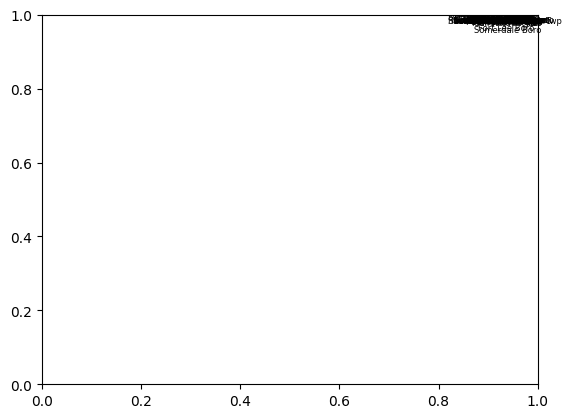

In [ ]:
from adjustText import adjust_text

texts = []

for _, row in map2024[map2024["can_active"] == 1].iterrows():
    texts.append(
        plt.text(
            row["label_point"].x,
            row["label_point"].y,
            row["muni_name"],
            fontsize=6
        )
    )

adjust_text(texts)

In [ ]:
print("CRS:", map2024.crs)
print("Geometry type:")
print(map2024.geometry.geom_type.value_counts())

print("\nMissing geometry:", map2024.geometry.isna().sum())

print("\nMap bounds:")
print(map2024.total_bounds)

CRS: EPSG:3424
Geometry type:
Polygon         550
MultiPolygon     14
Name: count, dtype: int64

Missing geometry: 0

Map bounds:
[193684.74502458  34945.75415374 657059.678181   919556.30841991]


In [ ]:
map2024.head()

,MUN,COUNTY,MUN_LABEL,MUN_TYPE,NAME,GNIS_NAME,GNIS,muni_id,MUN_CODE,CENSUS2020,...,optout15,optout20,actcomp5,actcomp10,actcomp15,actcomp20,near_active,onlyactive5,onlyactive10,label_point
0,CAPE MAY POINT BORO,CAPE MAY,Cape May Point Borough,Borough,Cape May Point Borough,Borough of Cape May Point,885179,0503,0503,3400910330,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (359612.907 38142.67)
1,WEST CAPE MAY BORO,CAPE MAY,West Cape May Borough,Borough,West Cape May Borough,Borough of West Cape May,885435,0512,0512,3400978530,...,17.736,26.030001,0.0,0.0,1.0,1.0,11.349293,1.0,1.0,POINT (367625.187 40059.153)
2,CAPE MAY CITY,CAPE MAY,Cape May City,City,Cape May,City of Cape May,885178,0502,0502,3400910270,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (377035.613 39225.249)
3,WILDWOOD CREST BORO,CAPE MAY,Wildwood Crest Borough,Borough,Wildwood Crest Borough,Borough of Wildwood Crest,885445,0515,0515,3400981200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (397165.923 50931.745)
4,WEST WILDWOOD BORO,CAPE MAY,West Wildwood Borough,Borough,West Wildwood Borough,Borough of West Wildwood,885441,0513,0513,3400980210,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (399977.803 61375.7)


<Axes: >

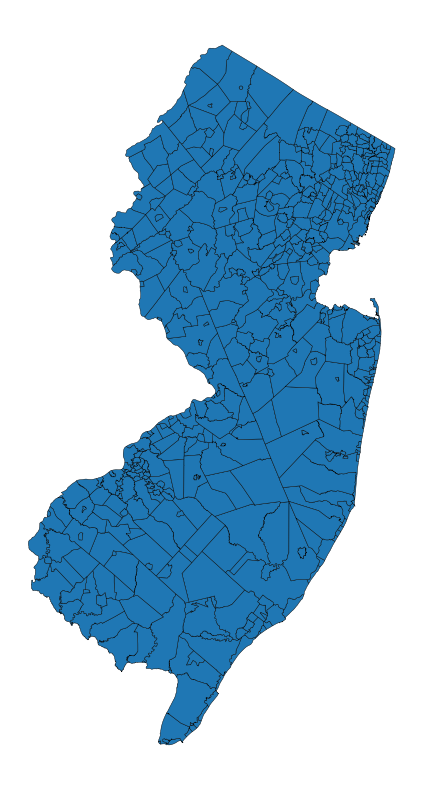

In [ ]:
fig, ax = plt.subplots(figsize=(8, 10))

map2024.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.3
)

ax.set_axis_off()

plt.show()

<Axes: >

Text(0.5, 1.0, 'Nearby Opt-Out Population Within 15 Miles\nActive Cannabis Municipalities, New Jersey, 2024')

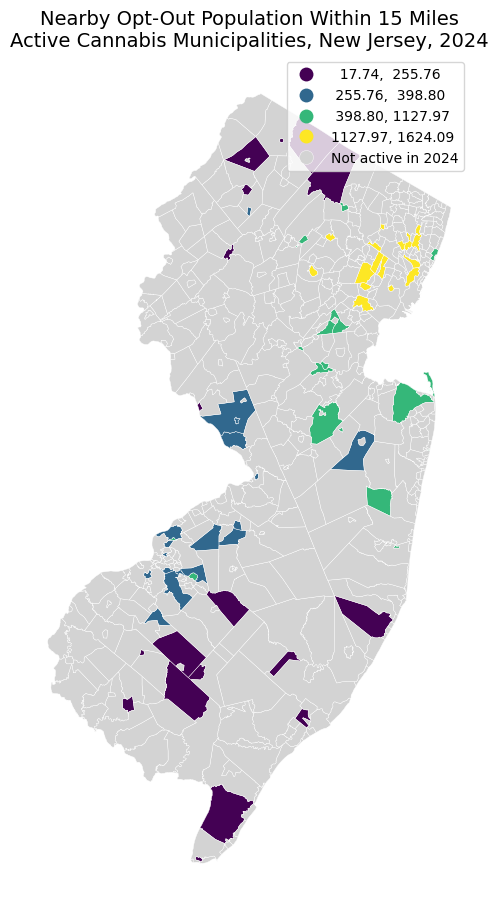

In [ ]:
fig, ax = plt.subplots(figsize=(9, 11))

map2024.plot(
    column="optout15",
    ax=ax,
    scheme="quantiles",
    k=4,
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    missing_kwds={
        "color": "lightgrey",
        "label": "Not active in 2024"
    }
)

ax.set_title(
    "Nearby Opt-Out Population Within 15 Miles\n"
    "Active Cannabis Municipalities, New Jersey, 2024",
    fontsize=14
)

ax.set_axis_off()

plt.show()

In [ ]:
from pathlib import Path

mydrive = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject")
for item in mydrive.iterdir():
    print(item)

/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/memo.docx
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424_6695002806283059598.xlsx
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/can_modified.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/prototype_spatial_variables
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/Task1_50RetailerPrototype
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/can_modified_upd.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/ext_dem.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/extdem_final.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/can_extdem.dta
/content/drive/MyDrive/2026_Dr. Hayes_SummerProject

In [ ]:
fullextdem = pd.read_stata(mydrive / "can_extdem.dta")
fullextdem.head()

,muni_id,muni_name,year,can_rev,can_rev_pcap,can_active,opted_in,eff_tax_rate,mri_score,dem_vote,eqprop_val,state_rev,pop,age65_over,ihs_can_rev_pcap,optout5,optout10,optout15,optout20
0,0101,Absecon City,2016,0.0,0.0,0.0,1.0,2.918781,-3.600225,50.310001,0.747806,0.757802,8.438,20.4,0.0,8.537,54.236000,68.176003,93.882004
1,0101,Absecon City,2017,0.0,0.0,0.0,1.0,3.096136,-3.600225,50.310001,0.727841,0.757802,8.370,21.2,0.0,8.480,53.889999,67.757004,93.334000
2,0101,Absecon City,2018,0.0,0.0,0.0,1.0,3.188293,-3.600225,50.310001,0.749576,0.757802,8.289,22.3,0.0,8.344,52.910000,66.730003,92.177002
3,0101,Absecon City,2019,0.0,0.0,0.0,1.0,3.076000,-3.036593,50.310001,0.743894,0.757802,8.362,22.8,0.0,8.153,52.130001,65.954002,91.341003
4,0101,Absecon City,2020,0.0,0.0,0.0,1.0,3.137155,-3.036593,50.310001,0.717707,0.757802,8.471,22.0,0.0,8.088,51.627998,65.568001,90.730003


In [ ]:
full2024 = fullextdem[
    fullextdem["year"] == 2024
].copy()

In [ ]:
print("Rows:", len(full2024))
print("Municipalities:", full2024["muni_id"].nunique())
print("Year:", full2024["year"].unique())

Rows: 564
Municipalities: 564
Year: [2024]


In [ ]:
print("Opt-in status:")
print(full2024["opted_in"].value_counts().sort_index())

print("\nActive cannabis status:")
print(full2024["can_active"].value_counts().sort_index())

Opt-in status:
opted_in
0.0    359
1.0    205
Name: count, dtype: int64

Active cannabis status:
can_active
0.0    495
1.0     69
Name: count, dtype: int64


In [ ]:
# Standardize IDs
njmuns["muni_id"] = njmuns["muni_id"].astype(str).str.zfill(4)
full2024["muni_id"] = full2024["muni_id"].astype(str).str.zfill(4)
cross2024["muni_id"] = cross2024["muni_id"].astype(str).str.zfill(4)

In [ ]:
map2024 = njmuns.merge(
    full2024[
        ["muni_id", "muni_name", "opted_in", "can_active"]
    ],
    on="muni_id",
    how="left"
)

In [ ]:
map2024 = map2024.merge(
    cross2024[
        ["muni_id", "optout5", "optout10", "optout15", "optout20"]
    ],
    on="muni_id",
    how="left"
)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import mapclassify

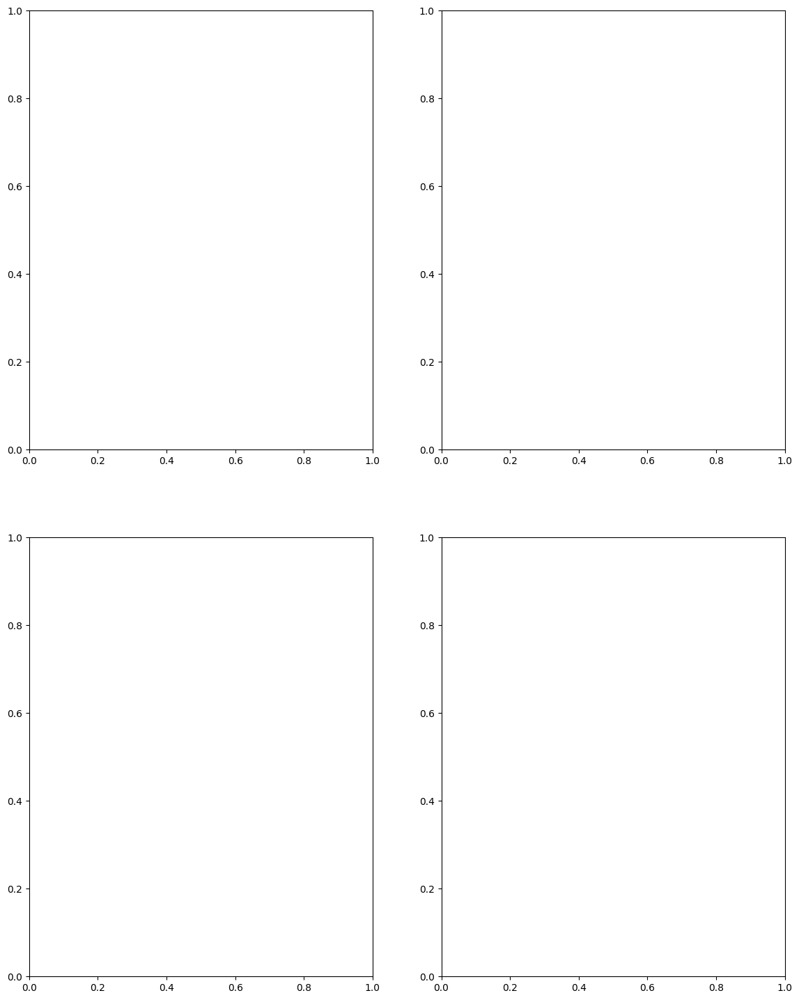

In [ ]:
radii = {
    "optout5": "Within 5 Miles",
    "optout10": "Within 10 Miles",
    "optout15": "Within 15 Miles",
    "optout20": "Within 20 Miles"
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 18)
)

axes = axes.flatten()

In [ ]:
for ax, (var, title) in zip(axes, radii.items()):

    # --------------------------------------------------
    # 1. Base layer: all NJ municipalities
    # --------------------------------------------------
    map2024.plot(
        ax=ax,
        color="#F4F1EA",
        edgecolor="white",
        linewidth=0.35
    )

    # --------------------------------------------------
    # 2. Opt-out municipalities = potential external-demand sources
    # --------------------------------------------------
    optout = map2024[
        map2024["opted_in"] == 0
    ]

    optout.plot(
        ax=ax,
        color="#F3B2AA",
        edgecolor="white",
        linewidth=0.35
    )

    # --------------------------------------------------
    # 3. Active municipalities
    # --------------------------------------------------
    active = map2024[
        map2024["can_active"] == 1
    ].copy()

    active.plot(
        column=var,
        ax=ax,
        scheme="quantiles",
        k=4,
        cmap="Greens",
        edgecolor="white",
        linewidth=0.55
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_axis_off()

<Axes: >

<Axes: >

<Axes: >

Text(0.5, 1.0, 'Within 5 Miles')

<Axes: >

...

Text(0.5, 1.0, 'Within 15 Miles')

<Axes: >

<Axes: >

<Axes: >

Text(0.5, 1.0, 'Within 20 Miles')

In [ ]:
fig.suptitle(
    "Potential External Demand Surrounding Active Cannabis Municipalities\n"
    "New Jersey, 2024",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

Text(0.5, 0.98, 'Potential External Demand Surrounding Active Cannabis Municipalities\nNew Jersey, 2024')

In [ ]:
# Adjust spacing so the main title does not overlap the four panels
plt.tight_layout(
    rect=[0.02, 0.03, 0.98, 0.94],
    h_pad=2.0,
    w_pad=1.5
)

# Display the completed figure
plt.show()

<Figure size 640x480 with 0 Axes>

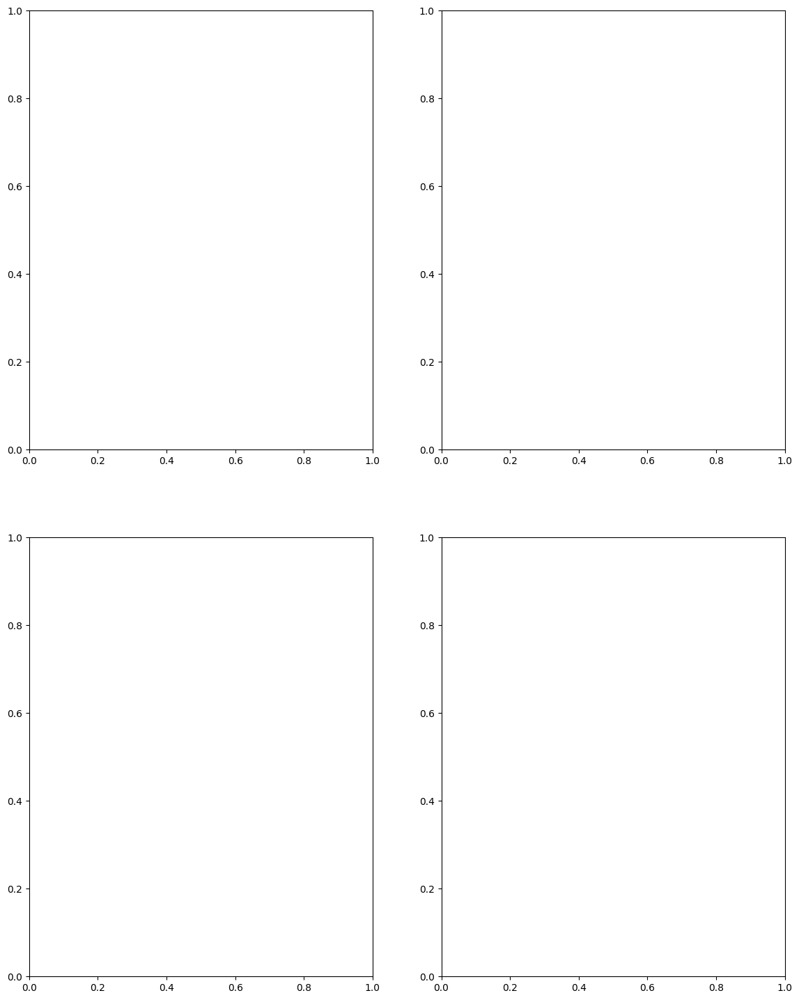

In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 18)
)

In [ ]:
print(type(map2024))
print(map2024.crs)
print("Rows:", len(map2024))
print("Missing geometry:", map2024.geometry.isna().sum())
print("Bounds:", map2024.total_bounds)

<class 'geopandas.geodataframe.GeoDataFrame'>
EPSG:3424
Rows: 564
Missing geometry: 0
Bounds: [193684.74502458  34945.75415374 657059.678181   919556.30841991]


<Axes: >

<Axes: >

<Axes: >

Text(0.5, 1.0, 'Nearby Opt-Out Population Within 5 Miles')

<Axes: >

...

<Axes: >

<Axes: >

<Axes: >

Text(0.5, 1.0, 'Nearby Opt-Out Population Within 20 Miles')

Text(0.5, 0.98, 'Potential External Demand Surrounding Active Cannabis Municipalities\nNew Jersey, 2024')

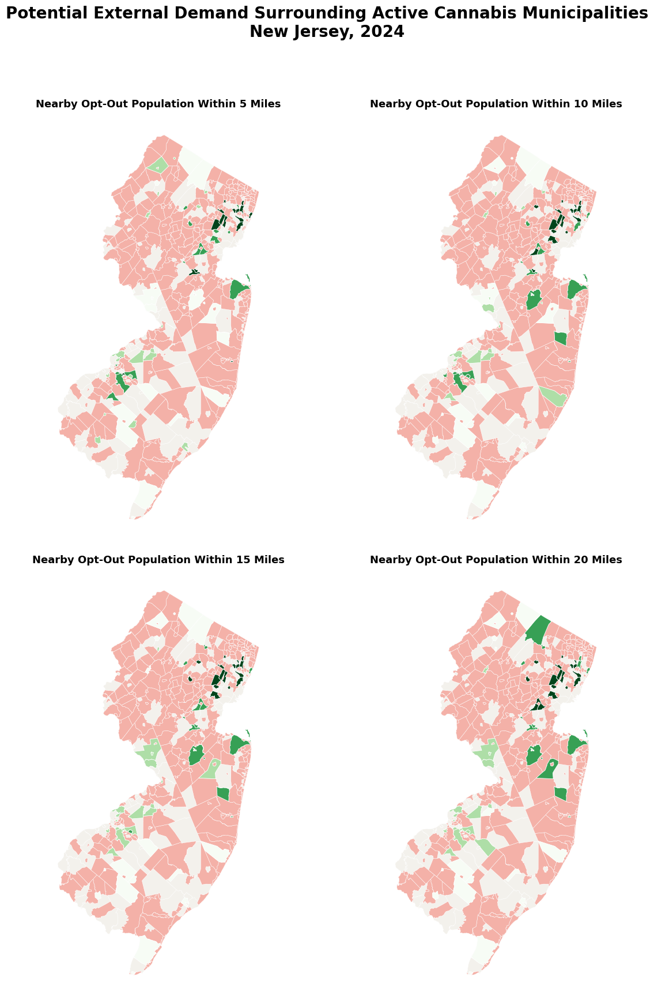

In [ ]:
import matplotlib.pyplot as plt

# External-demand measures and panel titles
radii = {
    "optout5": "5 Miles",
    "optout10": "10 Miles",
    "optout15": "15 Miles",
    "optout20": "20 Miles"
}

# Create figure
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 18)
)

axes = axes.flatten()

# ---------------------------------------------------------
# DRAW EACH PANEL
# ---------------------------------------------------------
for ax, (var, title) in zip(axes, radii.items()):

    # 1. Base: all NJ municipalities
    map2024.plot(
        ax=ax,
        color="#F3F1EC",
        edgecolor="white",
        linewidth=0.35
    )

    # 2. Opt-out municipalities:
    #    potential sources of external demand
    map2024.loc[
        map2024["opted_in"] == 0
    ].plot(
        ax=ax,
        color="#F4B1A8",       # light coral
        edgecolor="white",
        linewidth=0.35
    )

    # 3. Active cannabis municipalities:
    #    shade by nearby opt-out population
    active = map2024.loc[
        map2024["can_active"] == 1
    ].copy()

    active.plot(
        column=var,
        ax=ax,
        scheme="quantiles",
        k=4,
        cmap="Greens",
        edgecolor="white",
        linewidth=0.55
    )

    # Panel title
    ax.set_title(
        f"Nearby Opt-Out Population Within {title}",
        fontsize=13,
        fontweight="bold",
        pad=10
    )

    ax.set_axis_off()


# ---------------------------------------------------------
# MAIN FIGURE TITLE
# ---------------------------------------------------------
fig.suptitle(
    "Potential External Demand Surrounding Active Cannabis Municipalities\n"
    "New Jersey, 2024",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

# Layout
plt.tight_layout(
    rect=[0.02, 0.02, 0.98, 0.94],
    h_pad=2.0,
    w_pad=1.5
)

# Display
plt.show()

<Axes: >

<Axes: >

<Axes: >

Text(0.5, 1.0, 'Potential External Demand Surrounding Active Cannabis Municipalities\nNew Jersey, 2024')

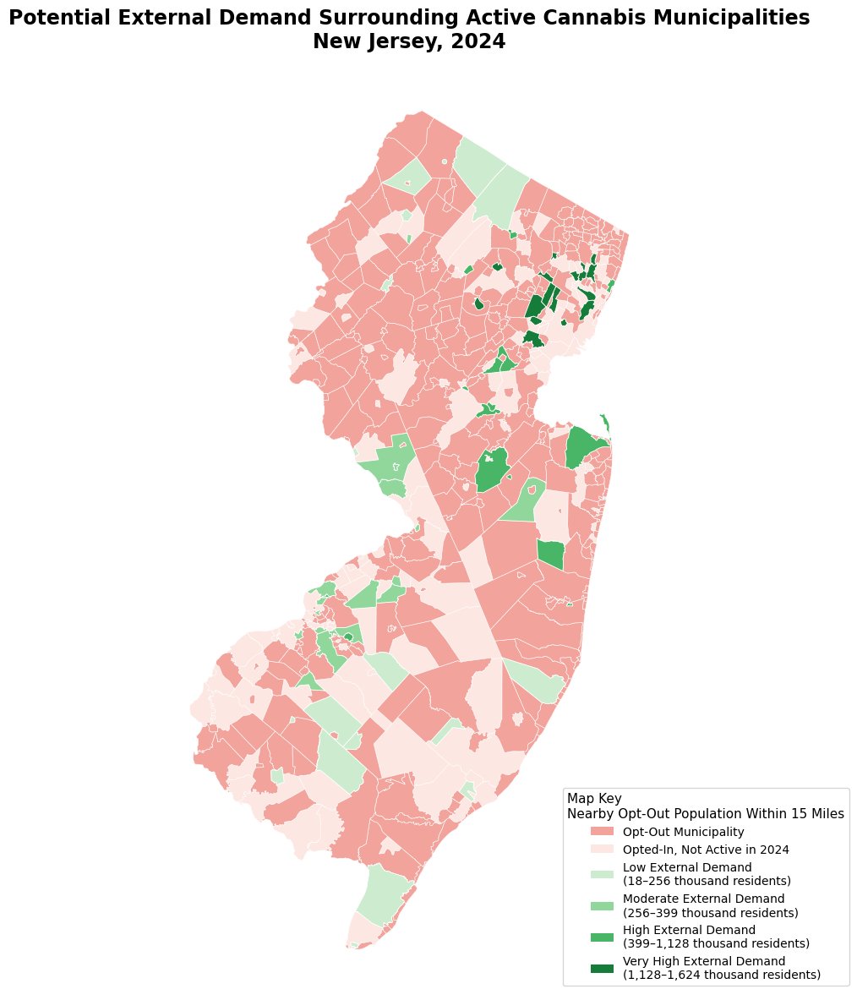

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ---------------------------------------------------------
# 1. CREATE THE ACTIVE-MUNICIPALITY DATA FOR THE MAP
# ---------------------------------------------------------

active = map2024.loc[
    map2024["can_active"] == 1
].copy()

# Divide active municipalities into quartiles of 15-mile external demand
active["extdem_group"], bins = pd.qcut(
    active["optout15"],
    q=4,
    labels=False,
    retbins=True,
    duplicates="drop"
)

# Green shades: light to dark
green_colors = [
    "#CDECCF",
    "#91D69A",
    "#49B667",
    "#167C3A"
]

green_cmap = ListedColormap(
    green_colors[:len(bins)-1]
)


# ---------------------------------------------------------
# 2. CREATE FIGURE
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 13)
)

# Leave space on the right/bottom for the legend
fig.subplots_adjust(
    right=0.78,
    bottom=0.08,
    top=0.92
)


# ---------------------------------------------------------
# 3. BASE LAYER:
#    ALL MUNICIPALITIES GET A LIGHT PINK BACKGROUND
# ---------------------------------------------------------

map2024.plot(
    ax=ax,
    color="#FCE7E3",
    edgecolor="white",
    linewidth=0.35
)


# ---------------------------------------------------------
# 4. ACTUAL OPT-OUT MUNICIPALITIES:
#    STRONGER CORAL
# ---------------------------------------------------------

map2024.loc[
    map2024["opted_in"] == 0
].plot(
    ax=ax,
    color="#F2A49C",
    edgecolor="white",
    linewidth=0.40
)


# ---------------------------------------------------------
# 5. ACTIVE CANNABIS MUNICIPALITIES:
#    LIGHT → DARK GREEN ACCORDING TO EXTERNAL DEMAND
# ---------------------------------------------------------

active.plot(
    column="extdem_group",
    ax=ax,
    categorical=True,
    cmap=green_cmap,
    edgecolor="white",
    linewidth=0.60
)


# ---------------------------------------------------------
# 6. TITLE
# ---------------------------------------------------------

ax.set_title(
    "Potential External Demand Surrounding Active Cannabis Municipalities\n"
    "New Jersey, 2024",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_axis_off()


# ---------------------------------------------------------
# 7. BUILD MEANINGFUL LEGEND
# ---------------------------------------------------------

legend_items = []

# Background categories
legend_items.append(
    mpatches.Patch(
        facecolor="#F2A49C",
        edgecolor="none",
        label="Opt-Out Municipality"
    )
)

legend_items.append(
    mpatches.Patch(
        facecolor="#FCE7E3",
        edgecolor="none",
        label="Opted-In, Not Active in 2024"
    )
)

# External-demand categories
demand_names = [
    "Low External Demand",
    "Moderate External Demand",
    "High External Demand",
    "Very High External Demand"
]

for i in range(len(bins) - 1):

    lower = bins[i]
    upper = bins[i + 1]

    label = (
        f"{demand_names[i]}\n"
        f"({lower:,.0f}–{upper:,.0f} thousand residents)"
    )

    legend_items.append(
        mpatches.Patch(
            facecolor=green_colors[i],
            edgecolor="none",
            label=label
        )
    )


# ---------------------------------------------------------
# 8. PLACE LEGEND AT LOWER RIGHT,
#    OUTSIDE THE MAP ITSELF
# ---------------------------------------------------------

fig.legend(
    handles=legend_items,
    title="Map Key\nNearby Opt-Out Population Within 15 Miles",
    loc="lower right",
    bbox_to_anchor=(0.98, 0.08),
    frameon=True,
    fontsize=10,
    title_fontsize=11
)


# ---------------------------------------------------------
# 9. DISPLAY
# ---------------------------------------------------------

plt.show()

In [ ]:
!pip install adjustText -q

In [ ]:
from adjustText import adjust_text
import numpy as np

<Axes: >

<Axes: >

<Axes: >

<Axes: >

<Axes: >

...

Text(347990.1583214621, 276397.8283352405, 'Franklin Twp')

Text(317770.286782692, 317688.61566819623, 'Glassboro Boro')

Text(308119.1738743351, 367068.26510424167, 'Woodbury City')

Text(561966.9737378301, 317960.9673216529, 'South Toms River Boro')

Text(397988.24254525837, 91955.77251536399, 'Middle Twp')

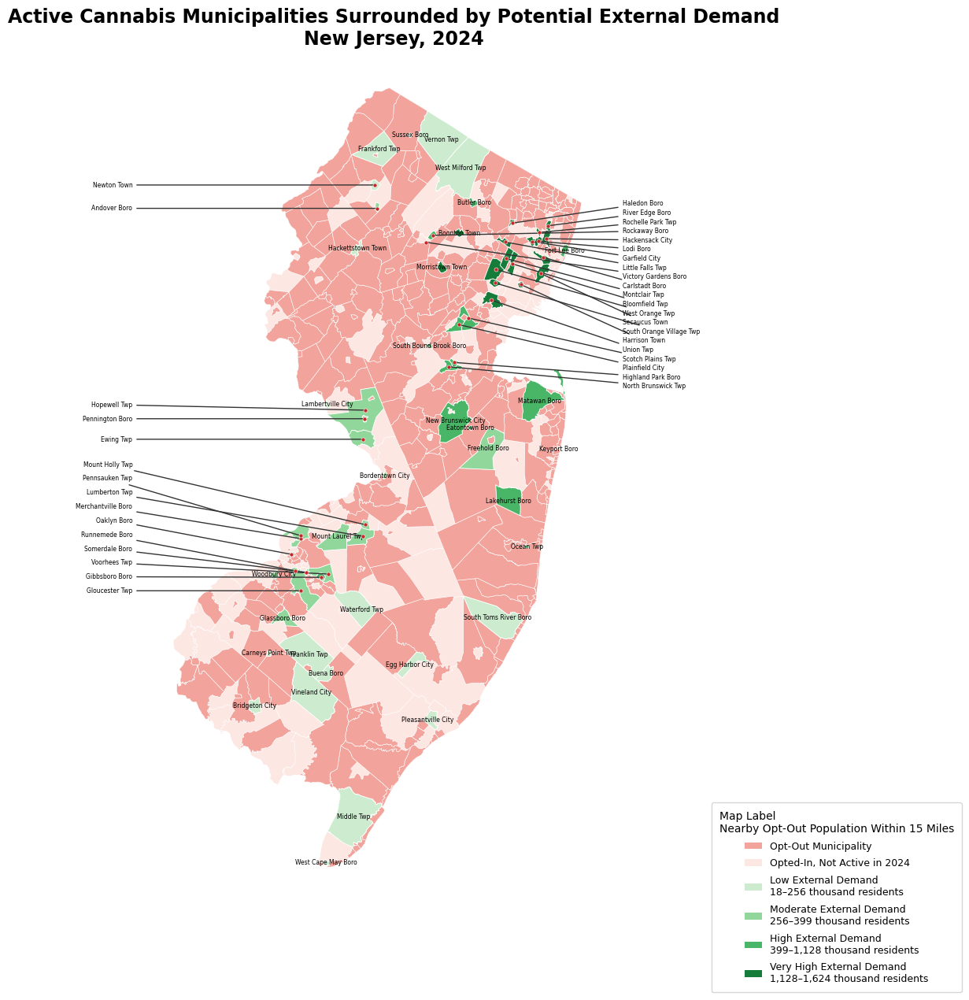

Final map displayed.


In [ ]:
# ============================================================
# FINAL NEW JERSEY EXTERNAL-DEMAND MAP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from matplotlib.lines import Line2D
from scipy.spatial import cKDTree


# ============================================================
# 1. ACTIVE MUNICIPALITIES
# ============================================================

active = map2024.loc[
    map2024["can_active"] == 1
].copy()

# Remove observations without the 15-mile external-demand measure
active = active.loc[
    active["optout15"].notna()
].copy()


# ============================================================
# 2. CREATE EXTERNAL-DEMAND QUARTILES
# ============================================================

active["extdem_group"], bins = pd.qcut(
    active["optout15"],
    q=4,
    labels=False,
    retbins=True,
    duplicates="drop"
)

active["extdem_group"] = active["extdem_group"].astype(int)


# ============================================================
# 3. COLORS
# ============================================================

# Background municipalities
base_color   = "#FCE7E3"   # pale pink
optout_color = "#F2A49C"   # coral

# Active municipalities: light → dark green
green_colors = [
    "#CDECCF",
    "#91D69A",
    "#49B667",
    "#167C3A"
]

# Red point at the municipality being labeled
marker_color = "#C62828"


# ============================================================
# 4. CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 15)
)

# Leave room on both sides for municipality labels
# and lower-right space for the legend
fig.subplots_adjust(
    left=0.05,
    right=0.80,
    bottom=0.08,
    top=0.91
)


# ============================================================
# 5. BASE LAYER — ALL MUNICIPALITIES
# ============================================================

map2024.plot(
    ax=ax,
    color=base_color,
    edgecolor="white",
    linewidth=0.35,
    zorder=1
)


# ============================================================
# 6. OPT-OUT MUNICIPALITIES
# ============================================================

map2024.loc[
    map2024["opted_in"] == 0
].plot(
    ax=ax,
    color=optout_color,
    edgecolor="white",
    linewidth=0.40,
    zorder=2
)


# ============================================================
# 7. ACTIVE MUNICIPALITIES — EXTERNAL DEMAND
# ============================================================

# Plot each quartile separately so the colors match
# the legend exactly.

for group in range(len(bins) - 1):

    active.loc[
        active["extdem_group"] == group
    ].plot(
        ax=ax,
        color=green_colors[group],
        edgecolor="white",
        linewidth=0.60,
        zorder=3
    )


# ============================================================
# 8. MAP TITLE
# ============================================================

ax.set_title(
    "Active Cannabis Municipalities Surrounded by Potential External Demand\n"
    "New Jersey, 2024",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_axis_off()


# ============================================================
# 9. CREATE REPRESENTATIVE POINTS FOR ACTIVE MUNICIPALITIES
# ============================================================

active_labels = active.copy()

active_labels["label_point"] = (
    active_labels.geometry.representative_point()
)

xmin, ymin, xmax, ymax = map2024.total_bounds

map_width  = xmax - xmin
map_height = ymax - ymin

center_x = (xmin + xmax) / 2


# ============================================================
# 10. IDENTIFY CROWDED ACTIVE MUNICIPALITIES
# ============================================================

# Normalize coordinates first
active_labels["x_norm"] = (
    active_labels["label_point"].x - xmin
) / map_width

active_labels["y_norm"] = (
    active_labels["label_point"].y - ymin
) / map_height

coords = np.column_stack([
    active_labels["x_norm"],
    active_labels["y_norm"]
])

tree = cKDTree(coords)

# Distance to nearest OTHER active municipality
distances, _ = tree.query(
    coords,
    k=2
)

active_labels["nearest_neighbor"] = distances[:, 1]


# ------------------------------------------------------------
# Increase this value if you want MORE labels outside the map.
# Decrease it if you want MORE labels directly on municipalities.
# ------------------------------------------------------------

crowd_threshold = 0.035

active_labels["crowded"] = (
    active_labels["nearest_neighbor"] < crowd_threshold
)


# ============================================================
# 11. SPLIT INTO CLEAR AND CROWDED LABELS
# ============================================================

clear_labels = active_labels.loc[
    ~active_labels["crowded"]
].copy()

crowded_labels = active_labels.loc[
    active_labels["crowded"]
].copy()


# Send crowded municipalities to whichever side is geographically closer
crowded_labels["side"] = np.where(
    crowded_labels["label_point"].x < center_x,
    "left",
    "right"
)

left_labels = crowded_labels.loc[
    crowded_labels["side"] == "left"
].copy()

right_labels = crowded_labels.loc[
    crowded_labels["side"] == "right"
].copy()


# ============================================================
# 12. EXPAND MAP AREA FOR OUTSIDE LABELS
# ============================================================

ax.set_xlim(
    xmin - map_width * 0.40,
    xmax + map_width * 0.48
)

ax.set_ylim(
    ymin - map_height * 0.03,
    ymax + map_height * 0.03
)

# Position of left/right municipality-name columns
left_x  = xmin - map_width * 0.10
right_x = xmax + map_width * 0.10


# ============================================================
# 13. KEEP UNCROWDED LABELS DIRECTLY ON/NEAR MUNICIPALITIES
# ============================================================

for _, row in clear_labels.iterrows():

    x = row["label_point"].x
    y = row["label_point"].y

    ax.text(
        x,
        y,
        row["muni_name"],
        fontsize=5.5,
        ha="center",
        va="center",
        color="black",
        zorder=12
    )


# ============================================================
# 14. FUNCTION FOR OUTSIDE LABELS
#     - STRAIGHT LEADER LINES
#     - THICKER LINES
#     - RED CIRCLE AT MUNICIPALITY
# ============================================================

def place_side_labels(df, side, x_text):

    if len(df) == 0:
        return

    df = df.copy()

    # Original municipality Y locations
    df["_actual_y"] = df["label_point"].apply(
        lambda p: p.y
    )

    # South → north ordering
    df = df.sort_values(
        "_actual_y"
    ).reset_index(drop=True)

    actual_y = df["_actual_y"].to_numpy()

    # Range occupied by these municipalities
    lower = actual_y.min() - map_height * 0.025
    upper = actual_y.max() + map_height * 0.025

    # Minimum vertical distance between labels
    min_gap = map_height * 0.018

    y_positions = actual_y.copy()

    # Push labels apart
    for i in range(1, len(y_positions)):

        if (
            y_positions[i] - y_positions[i - 1]
            < min_gap
        ):
            y_positions[i] = (
                y_positions[i - 1] + min_gap
            )

    # If pushing creates too much vertical expansion,
    # redistribute labels evenly.
    if (
        len(y_positions) > 1
        and y_positions[-1] > upper
    ):

        y_positions = np.linspace(
            lower,
            upper,
            len(df)
        )


    # --------------------------------------------------------
    # DRAW LABELS AND LINES
    # --------------------------------------------------------

    for i, row in df.iterrows():

        x0 = row["label_point"].x
        y0 = row["label_point"].y

        y_text = y_positions[i]

        if side == "left":
            horizontal_alignment = "right"
        else:
            horizontal_alignment = "left"


        # ----------------------------------------------------
        # RED CIRCLE EXACTLY AT MUNICIPALITY LOCATION
        # ----------------------------------------------------

        ax.scatter(
            x0,
            y0,
            s=13,
            facecolor=marker_color,
            edgecolor="white",
            linewidth=0.40,
            zorder=16
        )


        # ----------------------------------------------------
        # MUNICIPALITY NAME + ONE STRAIGHT LEADER LINE
        # ----------------------------------------------------

        ax.annotate(
            row["muni_name"],

            # Municipality endpoint
            xy=(x0, y0),

            # Name endpoint
            xytext=(x_text, y_text),

            fontsize=5.5,
            ha=horizontal_alignment,
            va="center",
            color="black",

            arrowprops=dict(
                arrowstyle="-",      # straight line, no arrowhead
                color="0.20",
                lw=1.00,             # thicker line
                shrinkA=2,
                shrinkB=1
            ),

            annotation_clip=False,
            zorder=15
        )


# ============================================================
# 15. DRAW LEFT AND RIGHT EXTERNAL LABELS
# ============================================================

place_side_labels(
    left_labels,
    side="left",
    x_text=left_x
)

place_side_labels(
    right_labels,
    side="right",
    x_text=right_x
)


# ============================================================
# 16. CREATE MAP LABEL
# ============================================================

legend_items = [

    mpatches.Patch(
        facecolor=optout_color,
        edgecolor="none",
        label="Opt-Out Municipality"
    ),

    mpatches.Patch(
        facecolor=base_color,
        edgecolor="none",
        label="Opted-In, Not Active in 2024"
    )
]


demand_names = [
    "Low External Demand",
    "Moderate External Demand",
    "High External Demand",
    "Very High External Demand"
]


# External-demand categories
for i in range(len(bins) - 1):

    lower = bins[i]
    upper = bins[i + 1]

    legend_items.append(
        mpatches.Patch(
            facecolor=green_colors[i],
            edgecolor="none",
            label=(
                f"{demand_names[i]}\n"
                f"{lower:,.0f}–{upper:,.0f} thousand residents"
            )
        )
    )


# ============================================================
# 17. PLACE "MAP LABEL" AT BOTTOM RIGHT
# ============================================================

fig.legend(
    handles=legend_items,

    title=(
        "Map Label\n"
        "Nearby Opt-Out Population Within 15 Miles"
    ),

    loc="lower right",

    # Bottom-right of entire figure
    bbox_to_anchor=(0.985, 0.055),

    frameon=True,
    fancybox=True,

    fontsize=9,
    title_fontsize=10,

    borderpad=0.8,
    labelspacing=0.7,
    handlelength=1.8
)


# ============================================================
# 18. DISPLAY FINAL MAP
# ============================================================

plt.show()

print("Final map displayed.")

<Axes: >

<Axes: >

<Axes: >

<Axes: >

<Axes: >

<Axes: >

Text(0.5, 1.0, 'Map of Potential External Demand Near Active Cannabis Municipalities\nNew Jersey, 2024')

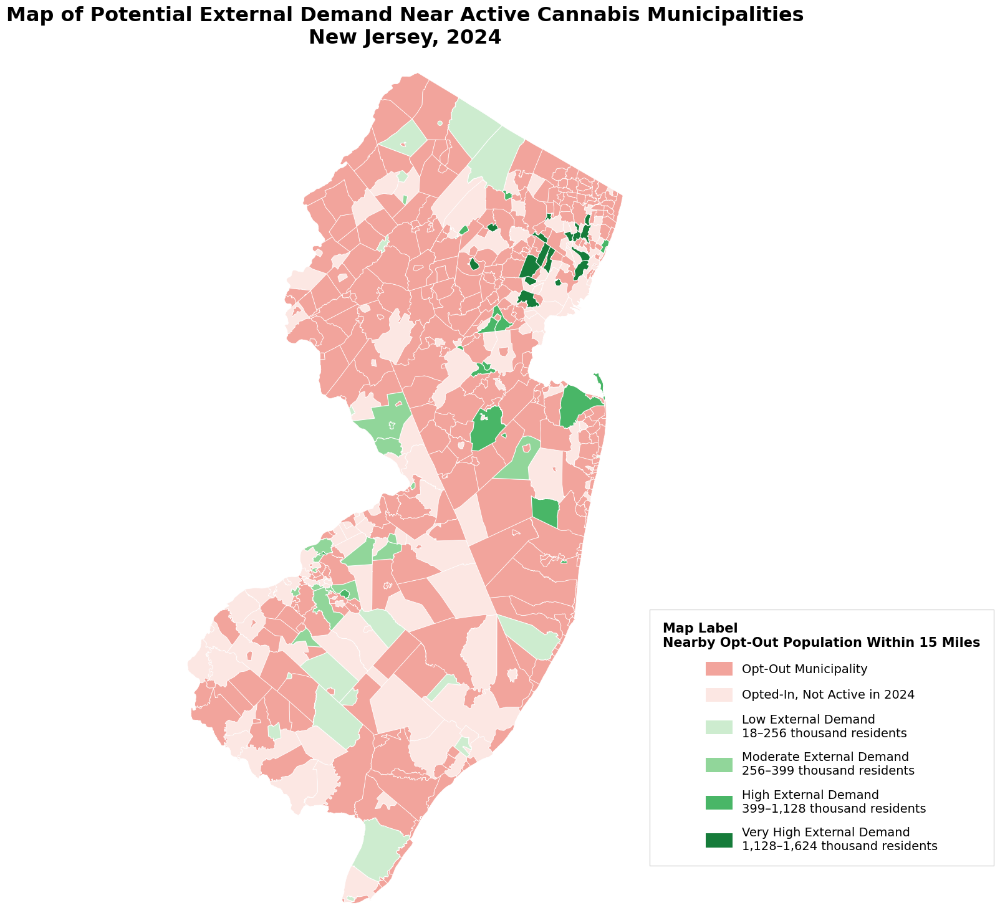

Presentation map displayed.


In [ ]:
# ============================================================
# PRESENTATION VERSION
# NO MUNICIPALITY NAME LABELS + LARGE READABLE LEGEND
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# ============================================================
# 1. ACTIVE MUNICIPALITIES
# ============================================================

active = map2024.loc[
    (map2024["can_active"] == 1) &
    (map2024["optout15"].notna())
].copy()


# ============================================================
# 2. CREATE EXTERNAL-DEMAND QUARTILES
# ============================================================

active["extdem_group"], bins = pd.qcut(
    active["optout15"],
    q=4,
    labels=False,
    retbins=True,
    duplicates="drop"
)

active["extdem_group"] = active["extdem_group"].astype(int)


# ============================================================
# 3. COLORS
# ============================================================

# Background
base_color = "#FCE7E3"       # Opted in, but not active
optout_color = "#F2A49C"     # Opt-out municipalities

# Active cannabis municipalities:
# light green --> dark green
green_colors = [
    "#CDECCF",
    "#91D69A",
    "#49B667",
    "#167C3A"
]


# ============================================================
# 4. CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(18, 16)
)

# Give more room to the map and a bit less reserved space to the legend
fig.subplots_adjust(
    left=0.03,
    right=0.88,
    bottom=0.05,
    top=0.90
)

ax.set_axis_off()
ax.margins(0.01)

# ============================================================
# 5. ALL NJ MUNICIPALITIES
# ============================================================

map2024.plot(
    ax=ax,
    color=base_color,
    edgecolor="white",
    linewidth=0.55,
    zorder=1
)


# ============================================================
# 6. OPT-OUT MUNICIPALITIES
# ============================================================

map2024.loc[
    map2024["opted_in"] == 0
].plot(
    ax=ax,
    color=optout_color,
    edgecolor="white",
    linewidth=0.55,
    zorder=2
)


# ============================================================
# 7. ACTIVE CANNABIS MUNICIPALITIES
#    SHADED BY 15-MILE EXTERNAL DEMAND
# ============================================================

for group in range(len(bins) - 1):

    active.loc[
        active["extdem_group"] == group
    ].plot(
        ax=ax,
        color=green_colors[group],
        edgecolor="white",
        linewidth=0.75,
        zorder=3
    )


# ============================================================
# 8. TITLE
# ============================================================

ax.set_title(
    "Map of Potential External Demand Near Active Cannabis Municipalities\n"
    "New Jersey, 2024",
    fontsize=23,
    fontweight="bold",
    pad=24
)

ax.set_axis_off()



# ============================================================
# 9. LARGE MAP LEGEND
# ============================================================

legend_items = [

    mpatches.Patch(
        facecolor=optout_color,
        edgecolor="none",
        label="Opt-Out Municipality"
    ),

    mpatches.Patch(
        facecolor=base_color,
        edgecolor="none",
        label="Opted-In, Not Active in 2024"
    )
]


demand_names = [
    "Low External Demand",
    "Moderate External Demand",
    "High External Demand",
    "Very High External Demand"
]


for i in range(len(bins) - 1):

    lower = bins[i]
    upper = bins[i + 1]

    legend_items.append(
        mpatches.Patch(
            facecolor=green_colors[i],
            edgecolor="none",
            label=(
                f"{demand_names[i]}\n"
                f"{lower:,.0f}–{upper:,.0f} thousand residents"
            )
        )
    )


# ============================================================
# 10. PLACE LARGE LEGEND AT BOTTOM RIGHT
# ============================================================

legend = fig.legend(
    handles=legend_items,

    title=(
        "Map Label\n"
        "Nearby Opt-Out Population Within 15 Miles"
    ),

    loc="lower right",
    bbox_to_anchor=(0.985, 0.09),

    frameon=True,
    fancybox=False,

    # Large enough for presentation
    fontsize=14,
    title_fontsize=15,

    # More generous spacing
    borderpad=1.1,
    labelspacing=1.0,
    handlelength=2.2,
    handleheight=1.4
)

# Make legend title stand out
legend.get_title().set_fontweight("bold")


# ============================================================
# 11. DISPLAY
# ============================================================

plt.show()

print("Presentation map displayed.")